# Importing libraries

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

colorarr = ['#0592D0','#Cd7f32', '#E97451', '#Bdb76b', '#954535', '#C2b280', '#808000','#C2b280', '#E4d008', '#9acd32', '#Eedc82', '#E4d96f',
           '#32cd32','#39ff14','#00ff7f', '#008080', '#36454f', '#F88379', '#Ff4500', '#Ffb347', '#A94064', '#E75480', '#Ffb6c1', '#E5e4e2',
           '#Faf0e6', '#8c92ac', '#Dbd7d2','#A7a6ba', '#B38b6d']

# Loading and exploring the dataset

In [8]:
PATH = '/content/Crop_recommendation2.csv'
df = pd.read_csv(PATH)

In [9]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [10]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [11]:
df.size

17600

In [12]:
df.shape

(2200, 8)

In [13]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [14]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [15]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


# Correlation matrices and heatmaps bold text

<Axes: >

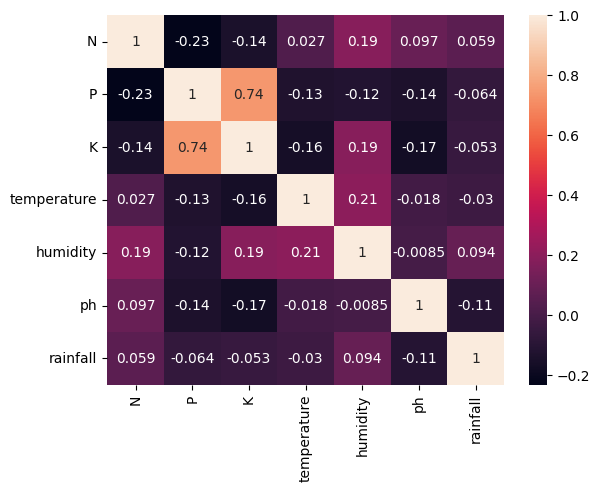

In [16]:
# Select only the numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True)

## Agricultural Parameter Averages Across Crop Types

In [17]:
grouped=df.groupby(by='label').mean().reset_index()
grouped

,label,N,P,K,temperature,humidity,ph,rainfall
0,apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
1,banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
2,blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
3,chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
4,coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
5,coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
6,cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
7,grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
8,jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798
9,kidneybeans,20.75,67.54,20.05,20.115085,21.605357,5.749411,105.919778


# Lowest Agricultural Parameter Requirements: Top 5 Crops

In [18]:
for i in grouped.columns[1:]:
    print(f'Top 5 least {i} requiring crops:')
    for j,k in grouped.sort_values(by=i)[:5][['label',i]].values:
        print(f'{j} -->{k}')
    print(f'***************************************')

Top 5 least N requiring crops:
lentil -->18.77
pomegranate -->18.87
orange -->19.58
mango -->20.07
pigeonpeas -->20.73
***************************************
Top 5 least P requiring crops:
orange -->16.55
coconut -->16.93
watermelon -->17.0
muskmelon -->17.72
pomegranate -->18.75
***************************************
Top 5 least K requiring crops:
orange -->10.01
blackgram -->19.24
lentil -->19.41
cotton -->19.56
maize -->19.79
***************************************
Top 5 least temperature requiring crops:
chickpea -->18.8728467519
kidneybeans -->20.1150846851
pomegranate -->21.837841721999997
maize -->22.3892039102
apple -->22.6309424132
***************************************
Top 5 least humidity requiring crops:
chickpea -->16.8604394237
kidneybeans -->21.6053567295
pigeonpeas -->48.0616330847
mango -->50.1565726953
mothbeans -->53.16041802790001
***************************************
Top 5 least ph requiring crops:
kidneybeans -->5.749410585870001
mango -->5.766372799660001
pi

# DATA VISUALIZATION AND ANALYSIS

nsights from Numerical Feature Visualizations


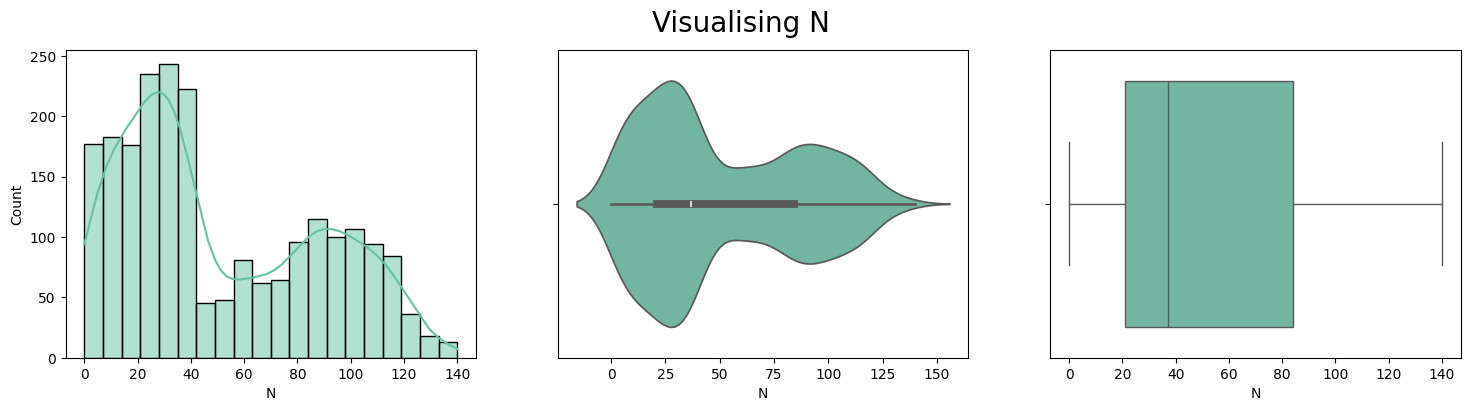

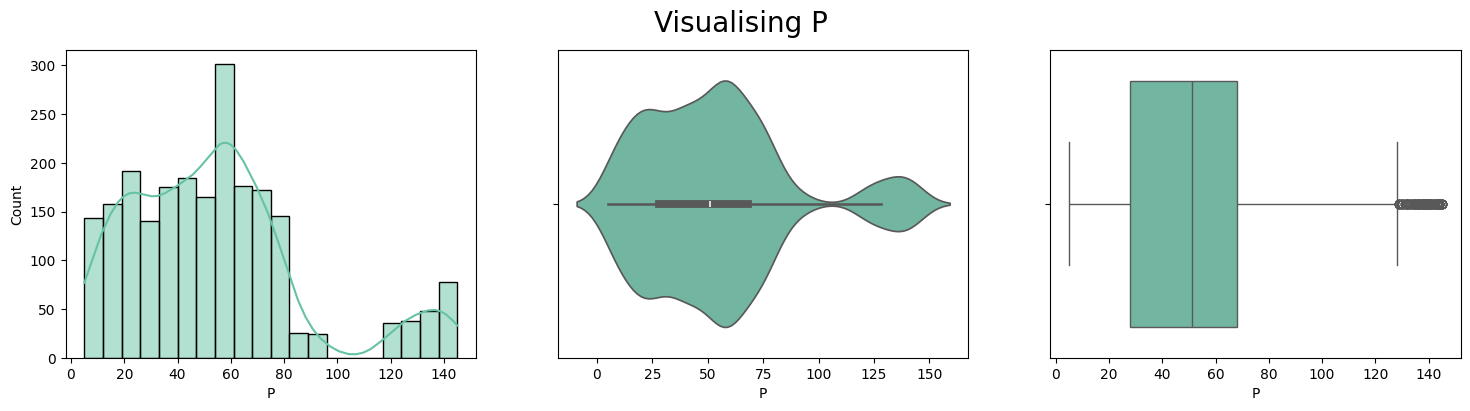

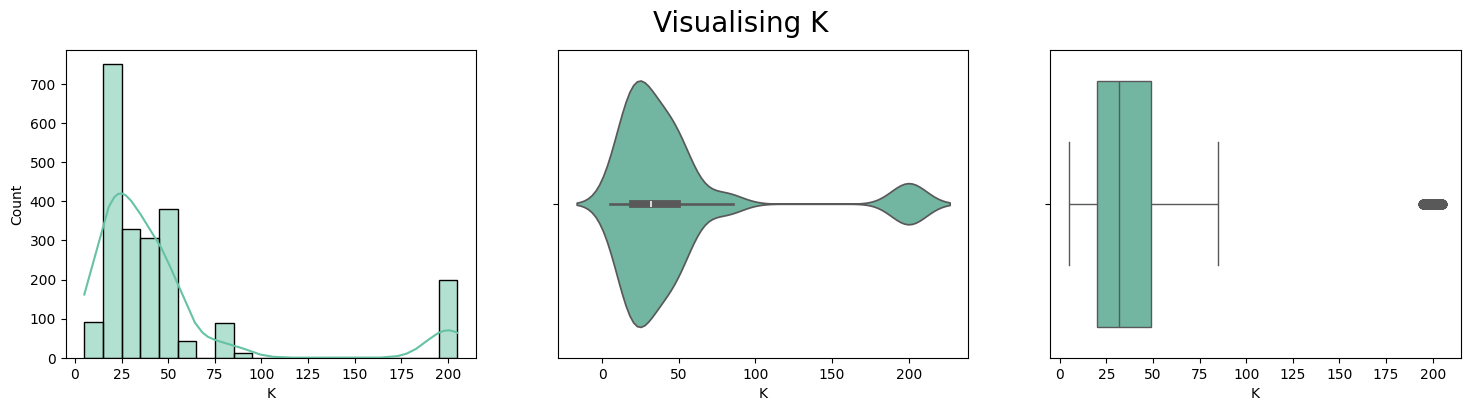

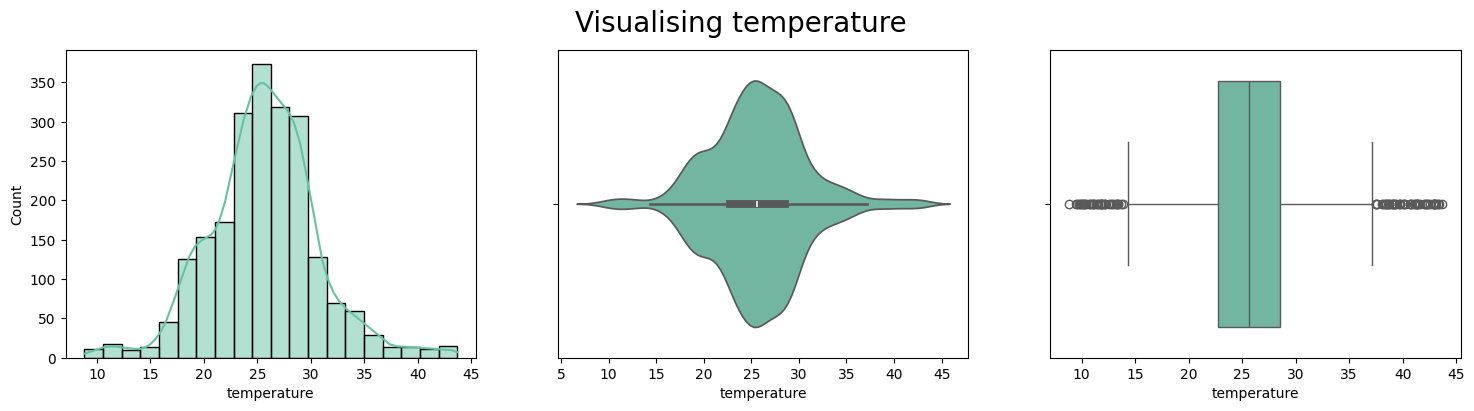

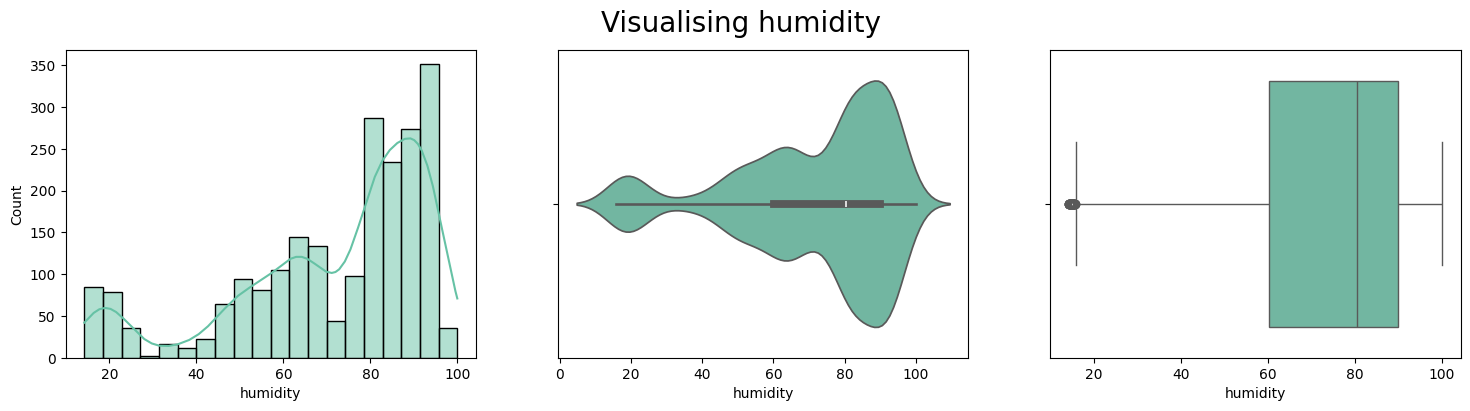

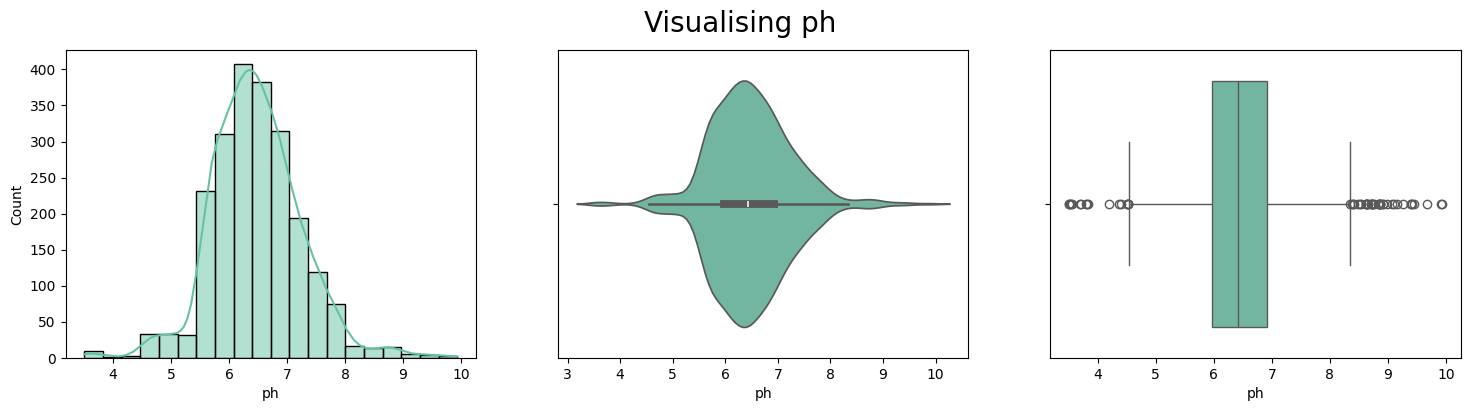

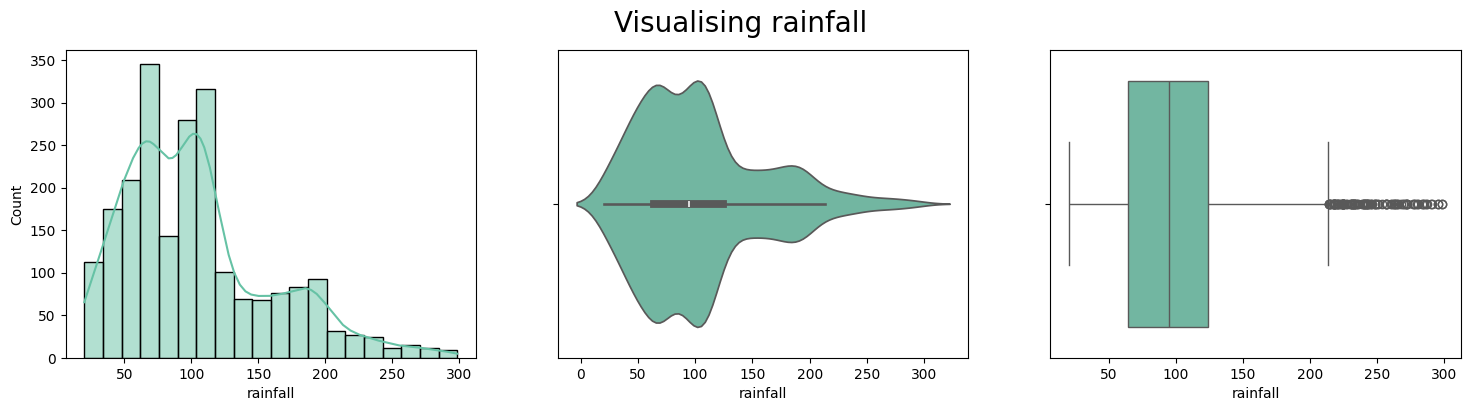

In [19]:
plt.style.use('fast')
sns.set_palette("Set2")
for i in df.columns[:-1]:
    fig,ax=plt.subplots(1,3,figsize=(18,4))
    sns.histplot(data=df,x=i,kde=True,bins=20, ax=ax[0])
    sns.violinplot(data=df,x=i,ax=ax[1])
    sns.boxplot(data=df,x=i,ax=ax[2])
    plt.suptitle(f'Visualising {i}',size=20)

In [20]:
crop_summary = pd.pivot_table(df,index=['label'],aggfunc='mean')
crop_summary.head()

,K,N,P,humidity,ph,rainfall,temperature
label,,,,,,,
apple,199.89,20.80,134.22,92.333383,5.929663,112.654779,22.630942
banana,50.05,100.23,82.01,80.358123,5.983893,104.626980,27.376798
blackgram,19.24,40.02,67.47,65.118426,7.133952,67.884151,29.973340
chickpea,79.92,40.09,67.79,16.860439,7.336957,80.058977,18.872847
coconut,30.59,21.98,16.93,94.844272,5.976562,175.686646,27.409892


Nitrogen Analysis

In [21]:
colorarr = ['blue', 'green', 'red', 'yellow', 'orange', 'purple']  # Add your desired colors

# Rest of your code
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import random

crop_summary_N = crop_summary.sort_values(by='N', ascending=False)

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.3)

top = {
    'y' : crop_summary_N['N'][0:11].sort_values().index,
    'x' : crop_summary_N['N'][0:11].sort_values()
}

last = {
    'y' : crop_summary_N['N'][-11:].index,
    'x' : crop_summary_N['N'][-11:]
}

fig.add_trace(
    go.Bar(top,
           name="Most nitrogen required",
           marker_color=random.choice(colorarr),  # This line uses 'random'
           orientation='h',
          text=top['x']),

    row=1, col=1
)

fig.add_trace(
    go.Bar(last,
           name="Least nitrogen required",
           marker_color=random.choice(colorarr),  # This line uses 'random'
           orientation='h',
          text=last['x']),
    row=1, col=2
)
fig.update_traces(texttemplate='%{text}', textposition='inside')
fig.update_layout(title_text="Nitrogen (N)",
                  plot_bgcolor='white',
                  font_size=12,
                  font_color='black',
                 height=500)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

Phosphorus Analysis

In [22]:
crop_summary_P = crop_summary.sort_values(by='P', ascending=False)

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.3)

top = {
    'y' : crop_summary_P['P'][0:11].sort_values().index,
    'x' : crop_summary_P['P'][0:11].sort_values()
}

last = {
    'y' : crop_summary_P['P'][-11:].index,
    'x' : crop_summary_P['P'][-11:]
}

fig.add_trace(
    go.Bar(top,
           name="Most phosphorus required",
           marker_color=random.choice(colorarr),
           orientation='h',
          text=top['x']),

    row=1, col=1
)
fig.add_trace(
    go.Bar(last,
           name="Least phosphorus required",
           marker_color=random.choice(colorarr),
           orientation='h',
          text=last['x']),
    row=1, col=2
)
fig.update_traces(texttemplate='%{text}', textposition='inside')
fig.update_layout(title_text="Phosphorus (P)",
                  plot_bgcolor='white',
                  font_size=12,
                  font_color='black',
                 height=500)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

Potassium analysis


In [23]:
crop_summary_K = crop_summary.sort_values(by='K', ascending=False)

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.3)

top = {
    'y' : crop_summary_K['K'][0:11].sort_values().index,
    'x' : crop_summary_K['K'][0:11].sort_values()
}

last = {
    'y' : crop_summary_K['K'][-11:].index,
    'x' : crop_summary_K['K'][-11:]
}

fig.add_trace(
    go.Bar(top,
           name="Most potassium required",
           marker_color=random.choice(colorarr),
           orientation='h',
          text=top['x']),

    row=1, col=1
)
fig.add_trace(
    go.Bar(last,
           name="Least potassium required",
           marker_color=random.choice(colorarr),
           orientation='h',
          text=last['x']),
    row=1, col=2
)
fig.update_traces(texttemplate='%{text}', textposition='inside')
fig.update_layout(title_text="Potassium (K)",
                  plot_bgcolor='white',
                  font_size=12,
                  font_color='black',
                 height=500)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

N, P, K values comparision between crops

In [24]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=crop_summary.index,
    y=crop_summary['N'],
    name='Nitrogen',
    marker_color='indianred'
))
fig.add_trace(go.Bar(
    x=crop_summary.index,
    y=crop_summary['P'],
    name='Phosphorous',
    marker_color='lightsalmon'
))
fig.add_trace(go.Bar(
    x=crop_summary.index,
    y=crop_summary['K'],
    name='Potash',
    marker_color='crimson'
))

fig.update_layout(title="N, P, K values comparision between crops",
                  plot_bgcolor='white',
                  barmode='group',
                  xaxis_tickangle=-45)

fig.show()

NPK ratio for rice, cotton, jute, maize, lentil

NPK ratio for fruits


Crop Scatterplot

# Comparision between rainfall, temerature and humidity

In [25]:
fig = px.bar(crop_summary, x=crop_summary.index, y=["rainfall", "temperature", "humidity"])
fig.update_layout(title_text="Comparision between rainfall, temerature and humidity",
                  plot_bgcolor='white',
                 height=500)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

# Decomposed using PCA

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca=PCA(n_components=2)
df_pca=pca.fit_transform(df.drop(['label'],axis=1))
df_pca=pd.DataFrame(df_pca)
fig=px.scatter(x=df_pca[0],y=df_pca[1],color=df['label'],title='Decomposed using PCA')
fig.show()

# 3D PCA Scatter Plot: Understanding Crop Environmental Relationships

In [28]:
pca2=PCA(n_components=3)
df_pca2=pca2.fit_transform(df.drop(['label'],axis=1))
df_pca2=pd.DataFrame(df_pca2)
fig=px.scatter_3d(x=df_pca2[0],y=df_pca2[1],z=df_pca2[2],color=df['label'],title="Variance explained;")
fig.show()

# Nitrogen VS phosphorus

In [29]:
fig = px.scatter (x=df['N'],y=df['P'],color=df['label'],title="Nitrogen VS phosphorus")
fig.show()

# Phosphorus VS Potassium

In [30]:
fig=px.scatter(x=df['P'],y=df['K'],color=df['label'],title='Phosphorus VS Potassium')
fig.show ()

# Correlation between different features

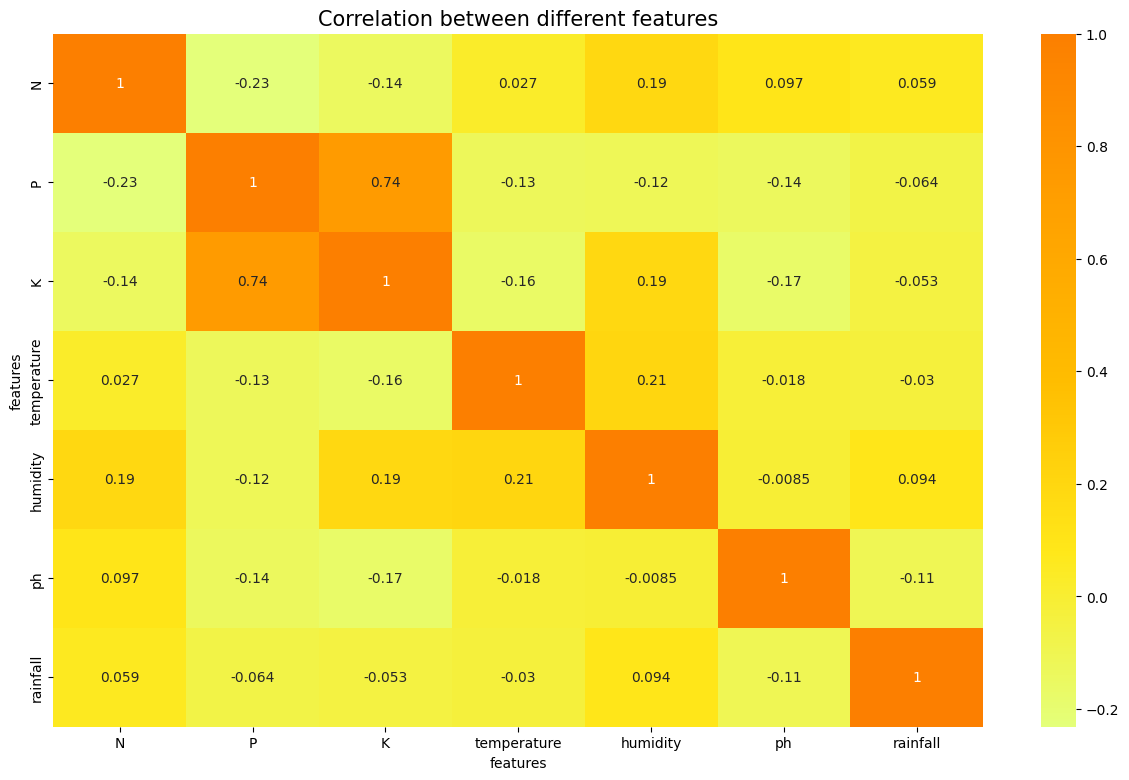

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(15, 9))
# Select only the numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True,cmap='Wistia')
ax.set(xlabel='features')
ax.set(ylabel='features')

plt.title('Correlation between different features', fontsize = 15, c='black')
plt.show()

In [32]:
names=df['label'].unique()
encoder =LabelEncoder()
df['label']=encoder.fit_transform(df['label'])
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [33]:
x=df.drop(['label'],axis=1)
y=df['label']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=.3,random_state=42)

In [34]:
scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtrain=pd.DataFrame(xtrain,columns=x.columns)
xtrain.head()

,N,P,K,temperature,humidity,ph,rainfall
0,-0.814149,-0.822608,-0.417587,0.291827,-1.109147,-1.008501,-0.114763
1,-0.599794,-0.552511,-0.398019,0.560394,-0.839739,0.640464,-0.212948
2,0.230832,-0.282414,-0.495859,-0.149479,-0.081354,-0.978596,-0.459356
3,0.766720,0.707944,0.012910,0.102227,0.348272,-1.243260,0.198403
4,0.230832,0.047706,-0.084930,-0.507217,0.482624,1.775630,2.914674


In [35]:
xtrain1,xtest1,ytrain1,ytest1=train_test_split(x,y,test_size=0.1,random_state=42)

In [36]:
models={'Logistic Regression1':LogisticRegression(),
        'Random Forest1':RandomForestClassifier(),
        'Tree1':DecisionTreeClassifier(),
        'SVC1':SVC(),
        'xGBoost1':XGBClassifier()
       }
def fit_and_Score(models,xtrain,xtest,ytrain,ytest):
    np.random.seed(42)
    model_score={}
    for name,model in models.items():
        model.fit(xtrain,ytrain)
        model_score[name]=model.score(xtest,ytest)
    return model_score

In [37]:
model_score= fit_and_Score(models,xtrain1,xtest1,ytrain1,ytest1)
model_score

{'Logistic Regression1': 0.9636363636363636,
 'Random Forest1': 1.0,
 'Tree1': 0.990909090909091,
 'SVC1': 0.9727272727272728,
 'xGBoost1': 0.9954545454545455}

In [38]:
features = df[['N', 'P','K','temperature', 'humidity', 'ph', 'rainfall']]
target = df['label']
labels = df['label']

In [39]:
# Initializing empty lists to append all model's name and corresponding name
acc1 = []
model1 = []
models_lr = []
models_rf = []
models_nb = []
models_dt = []
models_svm = []
models_xg = []
accuracy_train_lr = []
accuracy_train_rf = []
accuracy_train_nb = []
accuracy_train_dt = []
accuracy_train_svm = []
accuracy_train_xg = []
accuracy_test_lr = []
accuracy_test_rf = []
accuracy_test_nb = []
accuracy_test_dt = []
accuracy_test_svm = []
accuracy_test_xg = []

# Machine Learning Model Evaluation Process

**logistic** **regression**

Cross Validation Score (Logistic Regression)1: [0.93181818 0.9520202  0.96717172 0.96717172 0.96212121]
Logistic Regression Train Accuracy 90: 0.9681818181818181
Logistic Regression Test Accuracy: 10 0.9636363636363636
Confusion Matrix


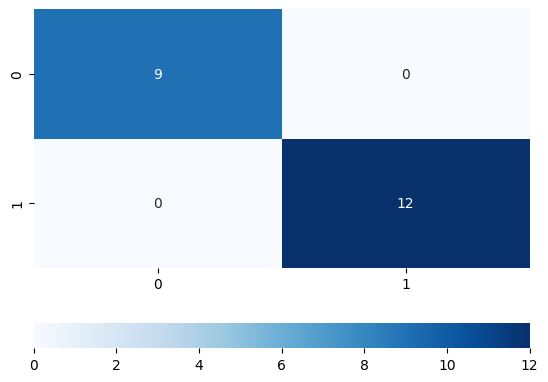

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       0.85      0.85      0.85        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00         9
           6       0.86      1.00      0.92         6
           7       1.00      1.00      1.00         8
           8       0.85      1.00      0.92        11
           9       1.00      1.00      1.00        13
          10       1.00      1.00      1.00         7
          11       1.00      0.83      0.91        12
          12       1.00      1.00      1.00         4
          13       0.83      0.91      0.87        11
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00         7
          16       1.00      1.00      1.00         9
          17       0.92    

In [40]:
# Logistic Regression
model_lr1 = LogisticRegression(random_state=42)
model_lr1.fit(xtrain1, ytrain1)

# Cross-validation score calculation
score_lr1 = cross_val_score(model_lr1, xtrain1, ytrain1, cv=5)
print("Cross Validation Score (Logistic Regression)1:", score_lr1)

# Train and test accuracy
train_score_lr1 = model_lr1.score(xtrain1, ytrain1)
test_score_lr1 = model_lr1.score(xtest1, ytest1)
print("Logistic Regression Train Accuracy 90:", train_score_lr1)
print("Logistic Regression Test Accuracy: 10", test_score_lr1)

# Append accuracy and model name to lists
acc1.append(test_score_lr1)
model1.append('Logistic Regression1')
models_lr.append('Logistic Regression1')
accuracy_train_lr.append(train_score_lr1)
accuracy_test_lr.append(test_score_lr1)


# Predictions and evaluation
y_pred_lr1 = model_lr1.predict(xtest1)
lr_acc1 = accuracy_score(y_pred_lr1, ytest1)

# Confusion matrix visualization
cm_lr1 = confusion_matrix(ytest1, y_pred_lr1, labels=[0,1])
print('Confusion Matrix')
sns.heatmap(cm_lr1, cmap='Blues', annot=True, cbar_kws={'orientation': 'horizontal'})
plt.show()

# Classification report printing
print(classification_report(ytest1, y_pred_lr1))
print('.:. Logistic Regression1:'+'\033[1m {:.3f}%'.format(lr_acc1*100)+' .:.')

# Calculate Precision, Recall, and F1 Score
y_true = ytest1
y_pred = y_pred_lr1

precision = precision_score(y_true, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")


**Randomforest**

Cross Validation Score (Random Forest)1: [0.98737374 0.99494949 0.99242424 0.99747475 0.99494949]
Random Forest Train Accuracy for 90: 1.0
Random Forest Test Accuracy for 10: 1.0
Confusion Matrix


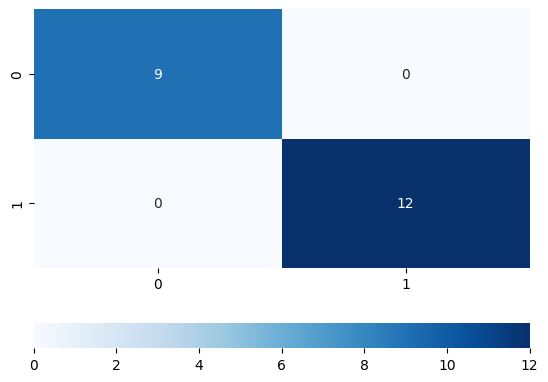

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00        11
           9       1.00      1.00      1.00        13
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00         4
          13       1.00      1.00      1.00        11
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00         7
          16       1.00      1.00      1.00         9
          17       1.00    

In [41]:
# Random Forest
model_rf1 = RandomForestClassifier(random_state=42)
model_rf1.fit(xtrain1, ytrain1)

# Cross-validation score calculation
score_rf1 = cross_val_score(model_rf1, xtrain1, ytrain1, cv=5)
print("Cross Validation Score (Random Forest)1:", score_rf1)

# Train and test accuracy
train_score_rf1 = model_rf1.score(xtrain1, ytrain1)
test_score_rf1 = model_rf1.score(xtest1, ytest1)
print("Random Forest Train Accuracy for 90:", train_score_rf1)
print("Random Forest Test Accuracy for 10:", test_score_rf1)

# Append accuracy and model name to lists
acc1.append(test_score_rf1)
model1.append('Random Forest1')
models_rf.append('Random Forest1')
accuracy_train_rf.append(train_score_rf1)
accuracy_test_rf.append(test_score_rf1)

# Predictions and evaluation
y_pred_rf1 = model_rf1.predict(xtest1)
rf_acc1 = accuracy_score(y_pred_rf1, ytest1)

# Confusion matrix visualization
cm_rf = confusion_matrix(ytest1, y_pred_rf1, labels=[0,1])
print('Confusion Matrix')
sns.heatmap(cm_rf, cmap='Blues', annot=True, cbar_kws={'orientation': 'horizontal'})
plt.show()

# Classification report printing
print(classification_report(ytest1, y_pred_rf1))
print('.:. Random Forest1:'+'\033[1m {:.3f}%'.format(rf_acc1*100)+' .:.')

# Calculate Precision, Recall, and F1 Score
y_true = ytest1
y_pred = y_pred_rf1

precision = precision_score(y_true, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")


**Gaussian Naive** **Bayes**

Cross Validation Score (Gaussian Naive Bayes)1: [0.98989899 0.99242424 0.99242424 1.         0.99747475]
Gaussian Naive Bayes Train Accuracy for 90: 0.9944444444444445
Gaussian Naive Bayes Test Accuracy for 10: 1.0
Confusion Matrix


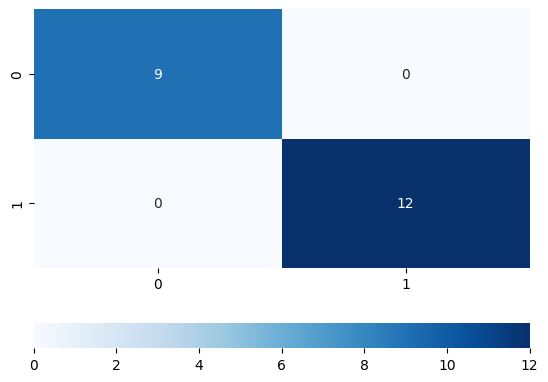

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00        11
           9       1.00      1.00      1.00        13
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00         4
          13       1.00      1.00      1.00        11
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00         7
          16       1.00      1.00      1.00         9
          17       1.00    

In [42]:
# Gaussian Naive Bayes
model_nb1 = GaussianNB()
model_nb1.fit(xtrain1, ytrain1)

# Cross-validation score calculation
score_nb1 = cross_val_score(model_nb1, xtrain1, ytrain1, cv=5)
print("Cross Validation Score (Gaussian Naive Bayes)1:", score_nb1)

# Train and test accuracy
train_score_nb1 = model_nb1.score(xtrain1, ytrain1)
test_score_nb1 = model_nb1.score(xtest1, ytest1)
print("Gaussian Naive Bayes Train Accuracy for 90:", train_score_nb1)
print("Gaussian Naive Bayes Test Accuracy for 10:", test_score_nb1)

# Append accuracy and model name to lists
acc1.append(test_score_nb1)
model1.append('Gaussian Naive Bayes1')
models_nb.append('Gaussian Naive Bayes1')
accuracy_train_nb.append(train_score_nb1)
accuracy_test_nb.append(test_score_nb1)

# Predictions and evaluation
y_pred_nb1 = model_nb1.predict(xtest1)
nb_acc1 = accuracy_score(y_pred_nb1, ytest1)

# Confusion matrix visualization
cm_nb = confusion_matrix(ytest1, y_pred_nb1, labels=[0,1])
print('Confusion Matrix')
sns.heatmap(cm_nb, cmap='Blues', annot=True, cbar_kws={'orientation': 'horizontal'})
plt.show()

# Classification report printing
print(classification_report(ytest1, y_pred_nb1))
print('.:. Gaussian Naive Bayes1:'+'\033[1m {:.3f}%'.format(nb_acc1*100)+' .:.')

# Calculate Precision, Recall, and F1 Score
y_true = ytest1
y_pred = y_pred_nb1

precision = precision_score(y_true, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

**decision tree**

Cross Validation Score (Decision Tree)1: [0.97979798 0.99494949 0.98232323 0.98232323 0.97979798]
Decision Tree Train Accuracy for 90: 1.0
Decision Tree Test Accuracy for 10: 0.990909090909091
Confusion Matrix


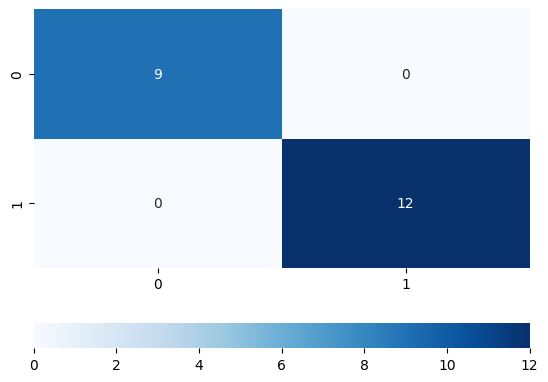

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.96        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00        11
           9       1.00      1.00      1.00        13
          10       1.00      1.00      1.00         7
          11       1.00      0.92      0.96        12
          12       1.00      1.00      1.00         4
          13       1.00      0.91      0.95        11
          14       0.91      1.00      0.95        10
          15       1.00      1.00      1.00         7
          16       1.00      1.00      1.00         9
          17       1.00    

In [43]:
# Decision Tree
model_dt1 = DecisionTreeClassifier(random_state=42)
model_dt1.fit(xtrain1, ytrain1)

# Cross-validation score calculation
score_dt1 = cross_val_score(model_dt1, xtrain1, ytrain1, cv=5)
print("Cross Validation Score (Decision Tree)1:", score_dt1)

# Train and test accuracy
train_score_dt1 = model_dt1.score(xtrain1, ytrain1)
test_score_dt1 = model_dt1.score(xtest1, ytest1)
print("Decision Tree Train Accuracy for 90:", train_score_dt1)
print("Decision Tree Test Accuracy for 10:", test_score_dt1)

# Append accuracy and model name to lists
acc1.append(test_score_dt1)
model1.append('Decision Tree1')
models_dt.append('Decision Tree1')
accuracy_train_dt.append(train_score_dt1)
accuracy_test_dt.append(test_score_dt1)

# Predictions and evaluation
y_pred_dt1 = model_dt1.predict(xtest1)
dt_acc1 = accuracy_score(y_pred_dt1, ytest1)

# Confusion matrix visualization
cm_dt = confusion_matrix(ytest1, y_pred_dt1, labels=[0,1])
print('Confusion Matrix')
sns.heatmap(cm_dt, cmap='Blues', annot=True, cbar_kws={'orientation': 'horizontal'})
plt.show()

# Classification report printing
print(classification_report(ytest1, y_pred_dt1))
print('.:. Decision Tree1:'+'\033[1m {:.3f}%'.format(dt_acc1*100)+' .:.')

# Calculate Precision, Recall, and F1 Score
y_true = ytest1
y_pred = y_pred_dt1

precision = precision_score(y_true, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

**svm**

Cross Validation Score (SVM)1: [0.96212121 0.97474747 0.98484848 0.98484848 0.98232323]
SVM Train Accuracy for 90: 0.9808080808080808
SVM Test Accuracy for 10: 0.9727272727272728
Confusion Matrix


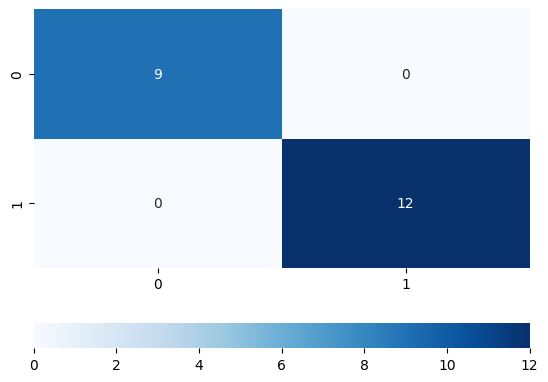

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       0.87      1.00      0.93        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00         9
           6       0.86      1.00      0.92         6
           7       1.00      1.00      1.00         8
           8       0.85      1.00      0.92        11
           9       1.00      1.00      1.00        13
          10       0.88      1.00      0.93         7
          11       1.00      0.92      0.96        12
          12       1.00      1.00      1.00         4
          13       1.00      0.91      0.95        11
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00         7
          16       1.00      1.00      1.00         9
          17       1.00    

In [44]:
# Support Vector Machine (SVM)
model_svm1 = SVC(random_state=42)
model_svm1.fit(xtrain1, ytrain1)

# Cross-validation score calculation
score_svm1 = cross_val_score(model_svm1, xtrain1, ytrain1, cv=5)
print("Cross Validation Score (SVM)1:", score_svm1)

# Train and test accuracy
train_score_svm1 = model_svm1.score(xtrain1, ytrain1)
test_score_svm1 = model_svm1.score(xtest1, ytest1)
print("SVM Train Accuracy for 90:", train_score_svm1)
print("SVM Test Accuracy for 10:", test_score_svm1)

# Append accuracy and model name to lists
acc1.append(test_score_svm1)
model1.append('SVM1')
models_svm.append('SVM1')
accuracy_train_svm.append(train_score_svm1)
accuracy_test_svm.append(test_score_svm1)

# Predictions and evaluation
y_pred_svm1 = model_svm1.predict(xtest1)
svm_acc1 = accuracy_score(y_pred_svm1, ytest1)

# Confusion matrix visualization
cm_svm = confusion_matrix(ytest1, y_pred_svm1, labels=[0,1])
print('Confusion Matrix')
sns.heatmap(cm_svm, cmap='Blues', annot=True, cbar_kws={'orientation': 'horizontal'})
plt.show()

# Classification report printing
print(classification_report(ytest1, y_pred_svm1))
print('.:. SVM1:'+'\033[1m {:.3f}%'.format(svm_acc1*100)+' .:.')

# Calculate Precision, Recall, and F1 Score
y_true = ytest1
y_pred = y_pred_svm1

precision = precision_score(y_true, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

**XGBoost**

Cross Validation Score (XGBoost): [0.97727273 0.98484848 0.99242424 0.98989899 0.99242424]
XGBoost Train Accuracy: 1.0
XGBoost Test Accuracy: 0.9954545454545455
Confusion Matrix


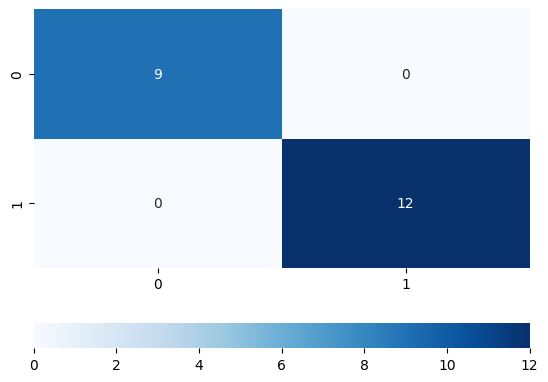

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.96        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00        11
           9       1.00      1.00      1.00        13
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00         4
          13       1.00      1.00      1.00        11
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00         7
          16       1.00      1.00      1.00         9
          17       1.00    

In [45]:
model_xg1 = XGBClassifier(random_state=42)
model_xg1.fit(xtrain1,ytrain1)

# Cross-validation score calculation
score_xgb1 = cross_val_score(model_xg1, xtrain1, ytrain1, cv=5)
print("Cross Validation Score (XGBoost):", score_xgb1)

# Train and test accuracy
train_score_xgb1 = model_xg1.score(xtrain1, ytrain1)
test_score_xgb1 = model_xg1.score(xtest1, ytest1)
print("XGBoost Train Accuracy:", train_score_xgb1)
print("XGBoost Test Accuracy:", test_score_xgb1)

# Append accuracy and model name to lists
acc1.append(test_score_xgb1)
model1.append('XGBoost1')
models_xg.append('XGBoost1')
accuracy_train_xg.append(train_score_xgb1)
accuracy_test_xg.append(test_score_xgb1)

# Predictions
y_pred_XGBC1 = model_xg1.predict(xtest1)
XGBAcc1 = accuracy_score(y_pred_XGBC1, ytest1)

# Confusion matrix visualization
cm=confusion_matrix(ytest1, y_pred_XGBC1, labels=[0,1])
print('Confusion Matrix')
sns.heatmap(cm,cmap='Blues',annot=True,cbar_kws= {'orientation':'horizontal'} )
plt.show()

# Classification report printing
print(classification_report(ytest1, y_pred_XGBC1))
print('.:. XGB Classifier1:'+'\033[1m {:.3f}%'.format(XGBAcc1*100)+' .:.')

# Calculate Precision, Recall, and F1 Score
y_true = ytest1
y_pred = y_pred_XGBC1

precision = precision_score(y_true, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

**Acuracy Comparison**

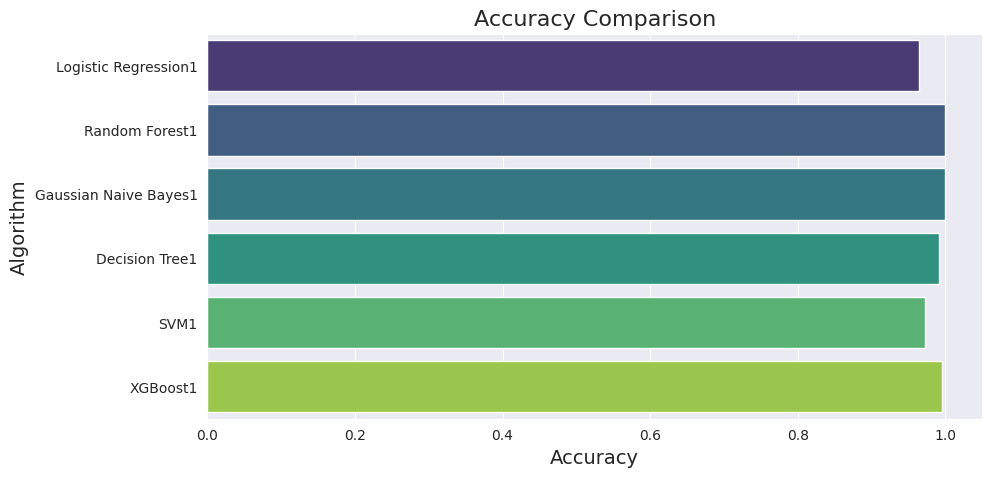

Logistic Regression1 --> 0.9636363636363636
Random Forest1 --> 1.0
Gaussian Naive Bayes1 --> 1.0
Decision Tree1 --> 0.990909090909091
SVM1 --> 0.9727272727272728
XGBoost1 --> 0.9954545454545455


In [46]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
plt.figure(figsize=[10,5], dpi=100)
plt.title('Accuracy Comparison', fontsize=16)
plt.xlabel('Accuracy', fontsize=14)
plt.ylabel('Algorithm', fontsize=14)

# Customize the barplot
sns.barplot(x=acc1, y=model1, palette='viridis')

# Show the plot
plt.show()

# Display accuracy values for each model
accuracy_models = dict(zip(model1, acc1))
for k, v in accuracy_models.items():
    print (k, '-->', v)

# Making a prediction

In [47]:
# New data for prediction
new_data = np.array([[80, 50, 45, 25.0, 70.0, 6.0, 150.0]])
# Make predictions using the trained Random Forest model
prediction1 = model_rf1.predict(new_data)
print("Prediction for data1:", prediction1)

Prediction for data1: [8]


In [48]:
# New data for prediction
data1 = np.array([[104, 18, 30, 23.603016, 60.3, 6.7, 140.91]])

# Make predictions using the trained Random Forest model
prediction1 = model_rf1.predict(data1)
print("Prediction for data1:", prediction1)

Prediction for data1: [5]


In [104]:
import numpy as np

# Manually define the crop list based on the dataset labels to avoid NameErrors
crops = ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
mapping = {i: name for i, name in enumerate(sorted(crops))}

# Set random seed for reproducibility
np.random.seed(42)

# Generate 5 random test samples
random_test_data = []
for i in range(5):
    sample = np.array([[
        np.random.randint(0, 140),              # N
        np.random.randint(5, 145),              # P
        np.random.randint(5, 205),              # K
        round(np.random.uniform(8, 44), 1),     # temperature
        round(np.random.uniform(14, 99), 1),    # humidity
        round(np.random.uniform(3.5, 9.9), 1),  # ph
        round(np.random.uniform(20, 298), 2)    # rainfall
    ]])
    random_test_data.append(sample)

# Compare model predictions with actual crop names
for i, data in enumerate(random_test_data, 1):
    print(f'--- Sample {i} --- Input: {data[0]}')

    # Using models from the 90:10 split (most accurate)
    try:
        res_svm = model_svm1.predict(data)[0]
        res_xgb = model_xg1.predict(data)[0]
        res_rf = model_rf1.predict(data)[0]
        res_nb = model_nb1.predict(data)[0]
        res_dt = model_dt1.predict(data)[0]
        res_lr = model_lr1.predict(data)[0]

        print(f'SVM Predicts                : {mapping.get(res_svm, res_svm)}')
        print(f'XGBoost Predicts            : {mapping.get(res_xgb, res_xgb)}')
        print(f'Random Forest Predicts      : {mapping.get(res_rf, res_rf)}')
        print(f'Naive Bayes Predicts        : {mapping.get(res_nb, res_nb)}')
        print(f'Decision Tree predicts      : {mapping.get(res_dt, res_dt)}')
        print(f'Logistic Regression predicts: {mapping.get(res_lr, res_lr)}')
    except NameError as e:
        print(f'Error: {e}. Please ensure the models (model_rf1, etc.) are trained.')
    print('-' * 30)

--- Sample 1 --- Input: [102.    97.    19.    34.4   64.9    4.5   63.37]
SVM Predicts                : banana
XGBoost Predicts            : banana
Random Forest Predicts      : maize
Naive Bayes Predicts        : maize
Decision Tree predicts      : blackgram
Logistic Regression predicts: maize
------------------------------
--- Sample 2 --- Input: [ 74.    92.   121.    29.6   74.2    3.6  289.63]
SVM Predicts                : papaya
XGBoost Predicts            : banana
Random Forest Predicts      : banana
Naive Bayes Predicts        : jute
Decision Tree predicts      : rice
Logistic Regression predicts: papaya
------------------------------
--- Sample 3 --- Input: [ 37.   134.   196.    43.7   66.5    7.4   21.96]
SVM Predicts                : grapes
XGBoost Predicts            : muskmelon
Random Forest Predicts      : grapes
Naive Bayes Predicts        : grapes
Decision Tree predicts      : muskmelon
Logistic Regression predicts: grapes
------------------------------
--- Sample 4 -

In [50]:
import pandas as pd

# Re-establishing the mapping from the encoder used in the training section
try:
    mapping = dict(zip(range(len(encoder.classes_)), encoder.classes_))
    print("--- Label Mapping (ID to Crop Name) ---")
    for crop_id, crop_name in mapping.items():
        print(f"{crop_id}: {crop_name}")
except NameError:
    print("Error: 'encoder' variable not found. Please ensure the cell containing 'encoder = LabelEncoder()' has been executed.")

--- Label Mapping (ID to Crop Name) ---
0: apple
1: banana
2: blackgram
3: chickpea
4: coconut
5: coffee
6: cotton
7: grapes
8: jute
9: kidneybeans
10: lentil
11: maize
12: mango
13: mothbeans
14: mungbean
15: muskmelon
16: orange
17: papaya
18: pigeonpeas
19: pomegranate
20: rice
21: watermelon


### Exporting Trained Models
We will use `pickle` to save the best-performing models to files for later use.

In [105]:
import pickle
from google.colab import files

# Save Random Forest model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(model_rf1, f)

# Save Gaussian Naive Bayes model
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(model_nb1, f)

# Save the LabelEncoder to ensure consistent label decoding in production
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

print("Models and Label Encoder have been serialized.")

# Automatically trigger downloads in the browser
files.download('random_forest_model.pkl')
files.download('naive_bayes_model.pkl')
files.download('label_encoder.pkl')

Models and Label Encoder have been serialized.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Train and Test Split is in ratio 80:20

In [51]:
xtrain2,xtest2,ytrain2,ytest2=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
models={'Logistic Regression2':LogisticRegression(),
        'Random Forest2':RandomForestClassifier(),
        'Tree2':DecisionTreeClassifier(),
        'SVC2':SVC(),
        'xGBoost2':XGBClassifier()
       }
def fit_and_Score(models,xtrain,xtest,ytrain,ytest):
    np.random.seed(42)
    model_score={}
    for name,model in models.items():
        model.fit(xtrain,ytrain)
        model_score[name]=model.score(xtest,ytest)
    return model_score

In [53]:
model_score= fit_and_Score(models,xtrain2,xtest2,ytrain2,ytest2)
model_score

{'Logistic Regression2': 0.9454545454545454,
 'Random Forest2': 0.9931818181818182,
 'Tree2': 0.9863636363636363,
 'SVC2': 0.9613636363636363,
 'xGBoost2': 0.9840909090909091}

In [54]:
# This cell was moved into the Logistic Regression model evaluation cell (R2upzYLpS4o3) to resolve a NameError.

In [55]:
acc2 = []
model2 = []

In [56]:
# Logistic Regression
model_lr2 = LogisticRegression(random_state=42)
model_lr2.fit(xtrain2, ytrain2)

# Train and test accuracy
train_score_lr2 = model_lr2.score(xtrain2, ytrain2)
test_score_lr2 = model_lr2.score(xtest2, ytest2)
print("Logistic Regression Train Accuracy for 80:", train_score_lr2)
print("Logistic Regression Test Accuracy for 20:", test_score_lr2)

# Append accuracy and model name to lists
acc2.append(test_score_lr2)
model2.append('Logistic Regression2')
models_lr.append('Logistic Regression2')
accuracy_test_lr.append(test_score_lr2)
accuracy_train_lr.append(train_score_lr2)

# Predictions and evaluation
y_pred_lr2 = model_lr2.predict(xtest2)
lr_acc2 = accuracy_score(y_pred_lr2, ytest2)
print(f"Accuracy Score: {lr_acc2:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest2
y_pred_current = y_pred_lr2

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Logistic Regression Train Accuracy for 80: 0.9761363636363637
Logistic Regression Test Accuracy for 20: 0.9454545454545454
Accuracy Score: 0.9455
Precision: 0.9466
Recall: 0.9455
F1 Score: 0.9450


In [57]:
# Random Forest
model_rf2 = RandomForestClassifier(random_state=42)
model_rf2.fit(xtrain2, ytrain2)

# Train and test accuracy
train_score_rf2 = model_rf2.score(xtrain2, ytrain2)
test_score_rf2 = model_rf2.score(xtest2, ytest2)
print("Random Forest Train Accuracy for 80:", train_score_rf2)
print("Random Forest Test Accuracy for 20:", test_score_rf2)

# Append accuracy and model name to lists
acc2.append(test_score_rf2)
model2.append('Random Forest2')
models_rf.append('Random Forest2')
accuracy_test_rf.append(test_score_rf2)
accuracy_train_rf.append(train_score_rf2)

# Predictions and evaluation
y_pred_rf2 = model_rf2.predict(xtest2)
rf_acc2 = accuracy_score(y_pred_rf2, ytest2)
print(f"Accuracy Score: {rf_acc2:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest2
y_pred_current = y_pred_rf2

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")


Random Forest Train Accuracy for 80: 1.0
Random Forest Test Accuracy for 20: 0.9931818181818182
Accuracy Score: 0.9932
Precision: 0.9937
Recall: 0.9932
F1 Score: 0.9932


In [58]:
# Gaussian Naive Bayes
model_nb2 = GaussianNB()
model_nb2.fit(xtrain2, ytrain2)

# Train and test accuracy
train_score_nb2 = model_nb2.score(xtrain2, ytrain2)
test_score_nb2 = model_nb2.score(xtest2, ytest2)
print("Gaussian Naive Bayes Train Accuracy for 80:", train_score_nb2)
print("Gaussian Naive Bayes Test Accuracy for 20:", test_score_nb2)

# Append accuracy and model name to lists
acc2.append(test_score_nb2)
model2.append('Gaussian Naive Bayes2')
models_nb.append('Gaussian Naive Bayes2')
accuracy_test_nb.append(test_score_nb2)
accuracy_train_nb.append(train_score_nb2)

# Predictions and evaluation
y_pred_nb2 = model_nb2.predict(xtest2)
nb_acc2 = accuracy_score(y_pred_nb2, ytest2)
print(f"Accuracy Score: {nb_acc2:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest2
y_pred_current = y_pred_nb2

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")


Gaussian Naive Bayes Train Accuracy for 80: 0.9948863636363636
Gaussian Naive Bayes Test Accuracy for 20: 0.9954545454545455
Accuracy Score: 0.9955
Precision: 0.9958
Recall: 0.9955
F1 Score: 0.9954


In [59]:
# Decision Tree
model_dt2 = DecisionTreeClassifier(random_state=42)
model_dt2.fit(xtrain2, ytrain2)

# Train and test accuracy
train_score_dt2 = model_dt2.score(xtrain2, ytrain2)
test_score_dt2 = model_dt2.score(xtest2, ytest2)
print("Decision Tree Train Accuracy for 80:", train_score_dt2)
print("Decision Tree Test Accuracy for 20:", test_score_dt2)


# Append accuracy and model name to lists
acc2.append(test_score_dt2)
model2.append('Decision Tree2')
models_dt.append('Decision Tree2')
accuracy_test_dt.append(test_score_dt2)
accuracy_train_dt.append(train_score_dt2)

# Predictions and evaluation
y_pred_dt2 = model_dt2.predict(xtest2)
dt_acc2 = accuracy_score(y_pred_dt2, ytest2)
print(f"Accuracy Score: {dt_acc2:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest2
y_pred_current = y_pred_dt2

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")


Decision Tree Train Accuracy for 80: 1.0
Decision Tree Test Accuracy for 20: 0.9863636363636363
Accuracy Score: 0.9864
Precision: 0.9868
Recall: 0.9864
F1 Score: 0.9863


In [60]:
# Support Vector Machine (SVM)
model_svm2 = SVC(random_state=42)
model_svm2.fit(xtrain2, ytrain2)

# Train and test accuracy
train_score_svm2 = model_svm2.score(xtrain2, ytrain2)
test_score_svm2 = model_svm2.score(xtest2, ytest2)
print("SVM Train Accuracy for 80:", train_score_svm2)
print("SVM Test Accuracy for 20:", test_score_svm2)

# Append accuracy and model name to lists
acc2.append(test_score_svm2)
model2.append('SVM2')
models_svm.append('SVM2')
accuracy_test_svm.append(test_score_svm2)
accuracy_train_svm.append(train_score_svm2)

# Predictions and evaluation
y_pred_svm2 = model_svm2.predict(xtest2)
svm_acc2 = accuracy_score(y_pred_svm2, ytest2)
print(f"Accuracy Score: {svm_acc2:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest2
y_pred_current = y_pred_svm2

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")


SVM Train Accuracy for 80: 0.98125
SVM Test Accuracy for 20: 0.9613636363636363
Accuracy Score: 0.9614
Precision: 0.9673
Recall: 0.9614
F1 Score: 0.9612


In [61]:
#XGBoost
model_xg2 = XGBClassifier(random_state=42)
model_xg2.fit(xtrain2,ytrain2)

# Train and test accuracy
train_score_xgb2 = model_xg2.score(xtrain2, ytrain2)
test_score_xgb2 = model_xg2.score(xtest2, ytest2)
print("XGBoost Train Accuracy for 80:", train_score_xgb2)
print("XGBoost Test Accuracy for 20:", test_score_xgb2)
# Append accuracy and model name to lists
acc2.append(test_score_xgb2)
model2.append('XGBoost2')
models_xg.append('XGBoost2')
accuracy_test_xg.append(test_score_xgb2)
accuracy_train_xg.append(train_score_xgb2)

# Predictions and evaluation
y_pred_xg2 = model_xg2.predict(xtest2)
xg_acc2 = accuracy_score(y_pred_xg2, ytest2)
print(f"Accuracy Score: {xg_acc2:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest2
y_pred_current = y_pred_xg2

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")


XGBoost Train Accuracy for 80: 1.0
XGBoost Test Accuracy for 20: 0.9840909090909091
Accuracy Score: 0.9841
Precision: 0.9847
Recall: 0.9841
F1 Score: 0.9841


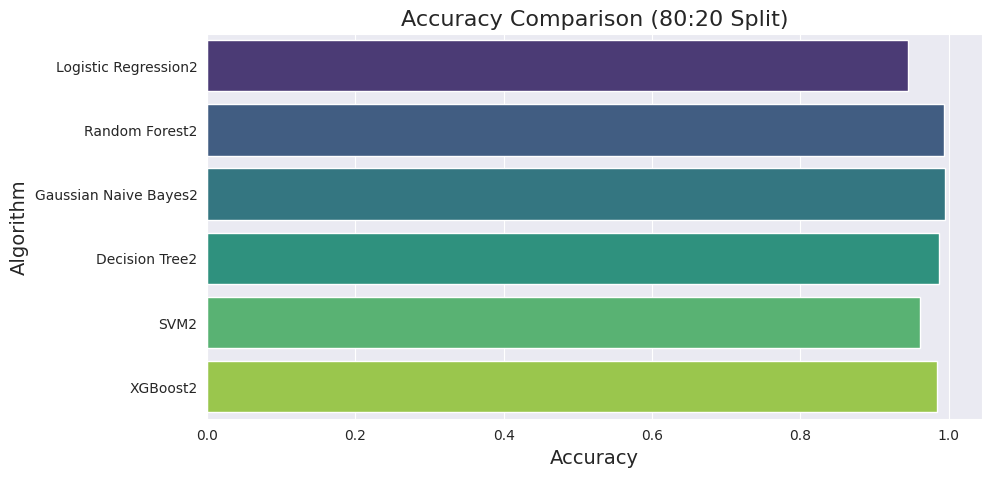

Logistic Regression2 --> 0.9454545454545454
Random Forest2 --> 0.9931818181818182
Gaussian Naive Bayes2 --> 0.9954545454545455
Decision Tree2 --> 0.9863636363636363
SVM2 --> 0.9613636363636363
XGBoost2 --> 0.9840909090909091


In [62]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
plt.figure(figsize=[10,5], dpi=100)
plt.title('Accuracy Comparison (80:20 Split)', fontsize=16)
plt.xlabel('Accuracy', fontsize=14)
plt.ylabel('Algorithm', fontsize=14)

# Customize the barplot
sns.barplot(x=acc2, y=model2, palette='viridis')

# Show the plot
plt.show()

# Display accuracy values for each model
accuracy_models = dict(zip(model2, acc2))
for k, v in accuracy_models.items():
    print (k, '-->', v)


# Test and Train Split 70:30

In [63]:
xtrain3,xtest3,ytrain3,ytest3=train_test_split(x,y,test_size=0.3,random_state=42)

In [64]:
models={'Logistic Regression3':LogisticRegression(),
        'Random Forest3':RandomForestClassifier(),
        'Tree3':DecisionTreeClassifier(),
        'SVC3':SVC(),
        'xGBoost3':XGBClassifier()
       }
def fit_and_Score(models,xtrain,xtest,ytrain,ytest):
    np.random.seed(42)
    model_score={}
    for name,model in models.items():
        model.fit(xtrain,ytrain)
        model_score[name]=model.score(xtest,ytest)
    return model_score

In [65]:
model_score= fit_and_Score(models,xtrain3,xtest3,ytrain3,ytest3)
model_score

{'Logistic Regression3': 0.946969696969697,
 'Random Forest3': 0.990909090909091,
 'Tree3': 0.9878787878787879,
 'SVC3': 0.9636363636363636,
 'xGBoost3': 0.9803030303030303}

In [66]:
acc3 =[]
model3 =[]

In [67]:
# Logistic Regression
model_lr3 = LogisticRegression(random_state=42)
model_lr3.fit(xtrain3, ytrain3)

# Train and test accuracy
train_score_lr3 = model_lr3.score(xtrain3, ytrain3)
test_score_lr3 = model_lr3.score(xtest3, ytest3)
print("Logistic Regression Train Accuracy for 70:", train_score_lr3)
print("Logistic Regression Test Accuracy for 30:", test_score_lr3)

# Append accuracy and model name to lists
acc3.append(test_score_lr3)
model3.append('Logistic Regression3')
models_lr.append('Logistic Regression3')
accuracy_test_lr.append(test_score_lr3)
accuracy_train_lr.append(train_score_lr3)

# Predictions and evaluation
y_pred_lr3 = model_lr3.predict(xtest3)
lr_acc3 = accuracy_score(y_pred_lr3, ytest3)
print(f"Accuracy Score: {lr_acc3:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest3
y_pred_current = y_pred_lr3

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Logistic Regression Train Accuracy for 70: 0.974025974025974
Logistic Regression Test Accuracy for 30: 0.946969696969697
Accuracy Score: 0.9470
Precision: 0.9482
Recall: 0.9470
F1 Score: 0.9466


In [68]:
# Random Forest
model_rf3 = RandomForestClassifier(random_state=42)
model_rf3.fit(xtrain3, ytrain3)

# Train and test accuracy
train_score_rf3 = model_rf3.score(xtrain3, ytrain3)
test_score_rf3 = model_rf3.score(xtest3, ytest3)
print("Random Forest Train Accuracy for 70:", train_score_rf3)
print("Random Forest Test Accuracy for 30:", test_score_rf3)

# Append accuracy and model name to lists
acc3.append(test_score_rf3)
model3.append('Random Forest3')
models_rf.append('Random Forest3')
accuracy_test_rf.append(test_score_rf3)
accuracy_train_rf.append(train_score_rf3)

# Predictions and evaluation
y_pred_rf3 = model_rf3.predict(xtest3)
rf_acc3 = accuracy_score(y_pred_rf3, ytest3)
print(f"Accuracy Score: {rf_acc3:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest3
y_pred_current = y_pred_rf3

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Random Forest Train Accuracy for 70: 1.0
Random Forest Test Accuracy for 30: 0.990909090909091
Accuracy Score: 0.9909
Precision: 0.9923
Recall: 0.9909
F1 Score: 0.9907


In [69]:
# Gaussian Naive Bayes
model_nb3 = GaussianNB()
model_nb3.fit(xtrain3, ytrain3)

# Train and test accuracy
train_score_nb3 = model_nb3.score(xtrain3, ytrain3)
test_score_nb3 = model_nb3.score(xtest3, ytest3)
print("Gaussian Naive Bayes Train Accuracy for 70:", train_score_nb3)
print("Gaussian Naive Bayes Test Accuracy for 30:", test_score_nb3)

# Append accuracy and model name to lists
acc3.append(test_score_nb3)
model3.append('Gaussian Naive Bayes3')
models_nb.append('Gaussian Naive Bayes3')
accuracy_test_nb.append(test_score_nb3)
accuracy_train_nb.append(train_score_nb3)

# Predictions and evaluation
y_pred_nb3 = model_nb3.predict(xtest3)
nb_acc3 = accuracy_score(y_pred_nb3, ytest3)
print(f"Accuracy Score: {nb_acc3:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest3
y_pred_current = y_pred_nb3

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Gaussian Naive Bayes Train Accuracy for 70: 0.9954545454545455
Gaussian Naive Bayes Test Accuracy for 30: 0.9939393939393939
Accuracy Score: 0.9939
Precision: 0.9946
Recall: 0.9939
F1 Score: 0.9939


In [70]:
# Decision Tree
model_dt3 = DecisionTreeClassifier(random_state=42)
model_dt3.fit(xtrain3, ytrain3)

# Train and test accuracy
train_score_dt3 = model_dt3.score(xtrain3, ytrain3)
test_score_dt3 = model_dt3.score(xtest3, ytest3)
print("Decision Tree Train Accuracy for 70:", train_score_dt3)
print("Decision Tree Test Accuracy for 30:", test_score_dt3)


# Append accuracy and model name to lists
acc3.append(test_score_dt3)
model3.append('Decision Tree3')
models_dt.append('Decision Tree3')
accuracy_test_dt.append(test_score_dt3)
accuracy_train_dt.append(train_score_dt3)

# Predictions and evaluation
y_pred_dt3 = model_dt3.predict(xtest3)
dt_acc3 = accuracy_score(y_pred_dt3, ytest3)
print(f"Accuracy Score: {dt_acc3:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest3
y_pred_current = y_pred_dt3

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Decision Tree Train Accuracy for 70: 1.0
Decision Tree Test Accuracy for 30: 0.9863636363636363
Accuracy Score: 0.9864
Precision: 0.9867
Recall: 0.9864
F1 Score: 0.9863


In [71]:
# Support Vector Machine (SVM)
model_svm3 = SVC(random_state=42)
model_svm3.fit(xtrain3, ytrain3)

# Train and test accuracy
train_score_svm3 = model_svm3.score(xtrain3, ytrain3)
test_score_svm3 = model_svm3.score(xtest3, ytest3)
print("SVM Train Accuracy for 70", train_score_svm3)
print("SVM Test Accuracy for 30:", test_score_svm3)

# Append accuracy and model name to lists
acc3.append(test_score_svm3)
model3.append('SVM3')
models_svm.append('SVM3')
accuracy_test_svm.append(test_score_svm3)
accuracy_train_svm.append(train_score_svm3)

# Predictions and evaluation
y_pred_svm3 = model_svm3.predict(xtest3)
svm_acc3 = accuracy_score(y_pred_svm3, ytest3)
print(f"Accuracy Score: {svm_acc3:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest3
y_pred_current = y_pred_svm3

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

SVM Train Accuracy for 70 0.9811688311688311
SVM Test Accuracy for 30: 0.9636363636363636
Accuracy Score: 0.9636
Precision: 0.9680
Recall: 0.9636
F1 Score: 0.9631


In [72]:
#XGBoost
model_xg3 = XGBClassifier(random_state=42)
model_xg3.fit(xtrain3,ytrain3)

# Train and test accuracy
train_score_xgb3 = model_xg3.score(xtrain3, ytrain3)
test_score_xgb3 = model_xg3.score(xtest3, ytest3)
print("XGBoost Train Accuracy for 70:", train_score_xgb3)
print("XGBoost Test Accuracy for 30:", test_score_xgb3)
# Append accuracy and model name to lists
acc3.append(test_score_xgb3)
model3.append('XGBoost3')
models_xg.append('XGBoost3')
accuracy_test_xg.append(test_score_xgb3)
accuracy_train_xg.append(train_score_xgb3)

# Predictions and evaluation
y_pred_xg3 = model_xg3.predict(xtest3)
xg_acc3 = accuracy_score(y_pred_xg3, ytest3)
print(f"Accuracy Score: {xg_acc3:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest3
y_pred_current = y_pred_xg3

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

XGBoost Train Accuracy for 70: 1.0
XGBoost Test Accuracy for 30: 0.9803030303030303
Accuracy Score: 0.9803
Precision: 0.9825
Recall: 0.9803
F1 Score: 0.9799


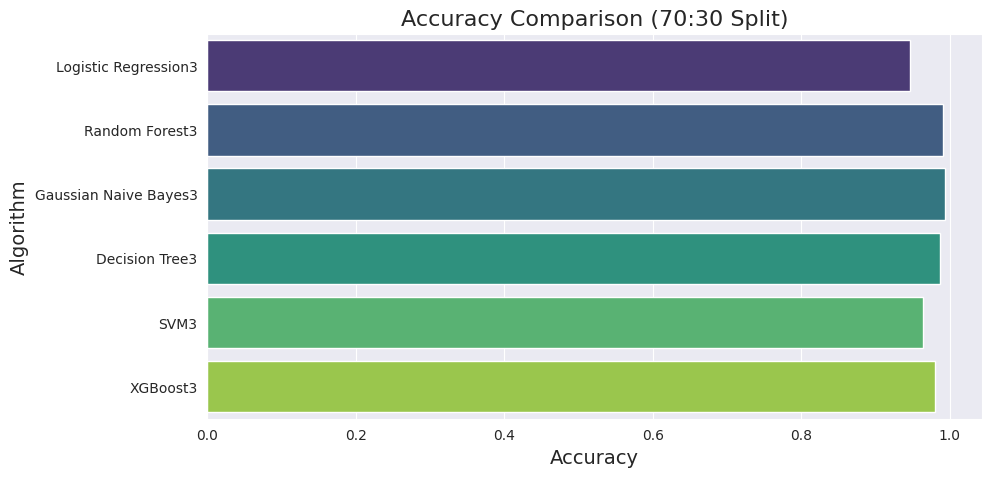

Logistic Regression3 --> 0.946969696969697
Random Forest3 --> 0.990909090909091
Gaussian Naive Bayes3 --> 0.9939393939393939
Decision Tree3 --> 0.9863636363636363
SVM3 --> 0.9636363636363636
XGBoost3 --> 0.9803030303030303


In [73]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
plt.figure(figsize=[10,5], dpi=100)
plt.title('Accuracy Comparison (70:30 Split)', fontsize=16)
plt.xlabel('Accuracy', fontsize=14)
plt.ylabel('Algorithm', fontsize=14)

# Customize the barplot
sns.barplot(x=acc3, y=model3, palette='viridis')

# Show the plot
plt.show()

# Display accuracy values for each model
accuracy_models = dict(zip(model3, acc3))
for k, v in accuracy_models.items():
    print (k, '-->', v)


# Train and Test Split ratio 60:40

In [74]:
xtrain4,xtest4,ytrain4,ytest4=train_test_split(x,y,test_size=0.4,random_state=42)

In [75]:
models={'Logistic Regression4':LogisticRegression(),
        'Random Forest4':RandomForestClassifier(),
        'Tree4':DecisionTreeClassifier(),
        'SVC4':SVC(),
        'xGBoost4':XGBClassifier()
       }
def fit_and_Score(models,xtrain,xtest,ytrain,ytest):
    np.random.seed(42)
    model_score={}
    for name,model in models.items():
        model.fit(xtrain,ytrain)
        model_score[name]=model.score(xtest,ytest)
    return model_score

In [76]:
model_score= fit_and_Score(models,xtrain4,xtest4,ytrain4,ytest4)
model_score

{'Logistic Regression4': 0.95,
 'Random Forest4': 0.9920454545454546,
 'Tree4': 0.9840909090909091,
 'SVC4': 0.9681818181818181,
 'xGBoost4': 0.9818181818181818}

In [77]:
acc4 =[]
model4 =[]

In [78]:
# Logistic Regression
model_lr4 = LogisticRegression(random_state=42)
model_lr4.fit(xtrain4, ytrain4)

# Train and test accuracy
train_score_lr4 = model_lr4.score(xtrain4, ytrain4)
test_score_lr4 = model_lr4.score(xtest4, ytest4)
print("Logistic Regression Train Accuracy for 60:", train_score_lr4)
print("Logistic Regression Test Accuracy for 40:", test_score_lr4)

# Append accuracy and model name to lists
acc4.append(test_score_lr4)
model4.append('Logistic Regression4')
models_lr.append('Logistic Regression4')
accuracy_test_lr.append(test_score_lr4)
accuracy_train_lr.append(train_score_lr4)

# Predictions and evaluation
y_pred_lr4 = model_lr4.predict(xtest4)
lr_acc4 = accuracy_score(y_pred_lr4, ytest4)
print(f"Accuracy Score: {lr_acc4:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest4
y_pred_current = y_pred_lr4

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Logistic Regression Train Accuracy for 60: 0.9727272727272728
Logistic Regression Test Accuracy for 40: 0.95
Accuracy Score: 0.9500
Precision: 0.9514
Recall: 0.9500
F1 Score: 0.9495


In [79]:
# Random Forest
model_rf4 = RandomForestClassifier(random_state=42)
model_rf4.fit(xtrain4, ytrain4)

# Train and test accuracy
train_score_rf4 = model_rf4.score(xtrain4, ytrain4)
test_score_rf4 = model_rf4.score(xtest4, ytest4)
print("Random Forest Train Accuracy for 60:", train_score_rf4)
print("Random Forest Test Accuracy for 40:", test_score_rf4)

# Append accuracy and model name to lists
acc4.append(test_score_rf4)
model4.append('Random Forest4')
models_rf.append('Random Forest4')
accuracy_test_rf.append(test_score_rf4)
accuracy_train_rf.append(train_score_rf4)

# Predictions and evaluation
y_pred_rf4 = model_rf4.predict(xtest4)
rf_acc4 = accuracy_score(y_pred_rf4, ytest4)
print(f"Accuracy Score: {rf_acc4:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest4
y_pred_current = y_pred_rf4

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Random Forest Train Accuracy for 60: 1.0
Random Forest Test Accuracy for 40: 0.9920454545454546
Accuracy Score: 0.9920
Precision: 0.9924
Recall: 0.9920
F1 Score: 0.9920


In [80]:
# Gaussian Naive Bayes
model_nb4 = GaussianNB()
model_nb4.fit(xtrain4, ytrain4)

# Train and test accuracy
train_score_nb4 = model_nb4.score(xtrain4, ytrain4)
test_score_nb4 = model_nb4.score(xtest4, ytest4)
print("Gaussian Naive Bayes Train Accuracy for 60:", train_score_nb4)
print("Gaussian Naive Bayes Test Accuracy for 40:", test_score_nb4)

# Append accuracy and model name to lists
acc4.append(test_score_nb4)
model4.append('Gaussian Naive Bayes4')
models_nb.append('Gaussian Naive Bayes4')
accuracy_test_nb.append(test_score_nb4)
accuracy_train_nb.append(train_score_nb4)

# Predictions and evaluation
y_pred_nb4 = model_nb4.predict(xtest4)
nb_acc4 = accuracy_score(y_pred_nb4, ytest4)
print(f"Accuracy Score: {nb_acc4:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest4
y_pred_current = y_pred_nb4

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Gaussian Naive Bayes Train Accuracy for 60: 0.9962121212121212
Gaussian Naive Bayes Test Accuracy for 40: 0.9931818181818182
Accuracy Score: 0.9932
Precision: 0.9932
Recall: 0.9932
F1 Score: 0.9932


In [81]:
# Decision Tree
model_dt4 = DecisionTreeClassifier(random_state=42)
model_dt4.fit(xtrain4, ytrain4)

# Train and test accuracy
train_score_dt4 = model_dt4.score(xtrain4, ytrain4)
test_score_dt4 = model_dt4.score(xtest4, ytest4)
print("Decision Tree Train Accuracy for 60:", train_score_dt4)
print("Decision Tree Test Accuracy for 40:", test_score_dt4)


# Append accuracy and model name to lists
acc4.append(test_score_dt4)
model4.append('Decision Tree4')
models_dt.append('Decision Tree4')
accuracy_test_dt.append(test_score_dt4)
accuracy_train_dt.append(train_score_dt4)

# Predictions and evaluation
y_pred_dt4 = model_dt4.predict(xtest4)
dt_acc4 = accuracy_score(y_pred_dt4, ytest4)
print(f"Accuracy Score: {dt_acc4:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest4
y_pred_current = y_pred_dt4

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Decision Tree Train Accuracy for 60: 1.0
Decision Tree Test Accuracy for 40: 0.9852272727272727
Accuracy Score: 0.9852
Precision: 0.9857
Recall: 0.9852
F1 Score: 0.9852


In [82]:
# Support Vector Machine (SVM)
model_svm4 = SVC(random_state=42)
model_svm4.fit(xtrain4, ytrain4)

# Train and test accuracy
train_score_svm4 = model_svm4.score(xtrain4, ytrain4)
test_score_svm4 = model_svm4.score(xtest4, ytest4)
print("SVM Train Accuracy for 60", train_score_svm4)
print("SVM Test Accuracy for 40:", test_score_svm4)

# Append accuracy and model name to lists
acc4.append(test_score_svm4)
model4.append('SVM4')
models_svm.append('SVM4')
accuracy_test_svm.append(test_score_svm4)
accuracy_train_svm.append(train_score_svm4)

# Predictions and evaluation
y_pred_svm4 = model_svm4.predict(xtest4)
svm_acc4 = accuracy_score(y_pred_svm4, ytest4)
print(f"Accuracy Score: {svm_acc4:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest4
y_pred_current = y_pred_svm4

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

SVM Train Accuracy for 60 0.9810606060606061
SVM Test Accuracy for 40: 0.9681818181818181
Accuracy Score: 0.9682
Precision: 0.9721
Recall: 0.9682
F1 Score: 0.9677


In [83]:
#XGBoost
model_xg4 = XGBClassifier(random_state=42)
model_xg4.fit(xtrain4,ytrain4)

# Train and test accuracy
train_score_xgb4 = model_xg4.score(xtrain4, ytrain4)
test_score_xgb4 = model_xg4.score(xtest4, ytest4)
print("XGBoost Train Accuracy for 60:", train_score_xgb4)
print("XGBoost Test Accuracy for 40:", test_score_xgb4)
# Append accuracy and model name to lists
acc4.append(test_score_xgb4)
model4.append('XGBoost4')
models_xg.append('XGBoost4')
accuracy_test_xg.append(test_score_xgb4)
accuracy_train_xg.append(train_score_xgb4)

# Predictions and evaluation
y_pred_xg4 = model_xg4.predict(xtest4)
xg_acc4 = accuracy_score(y_pred_xg4, ytest4)
print(f"Accuracy Score: {xg_acc4:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest4
y_pred_current = y_pred_xg4

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

XGBoost Train Accuracy for 60: 1.0
XGBoost Test Accuracy for 40: 0.9818181818181818
Accuracy Score: 0.9818
Precision: 0.9829
Recall: 0.9818
F1 Score: 0.9819


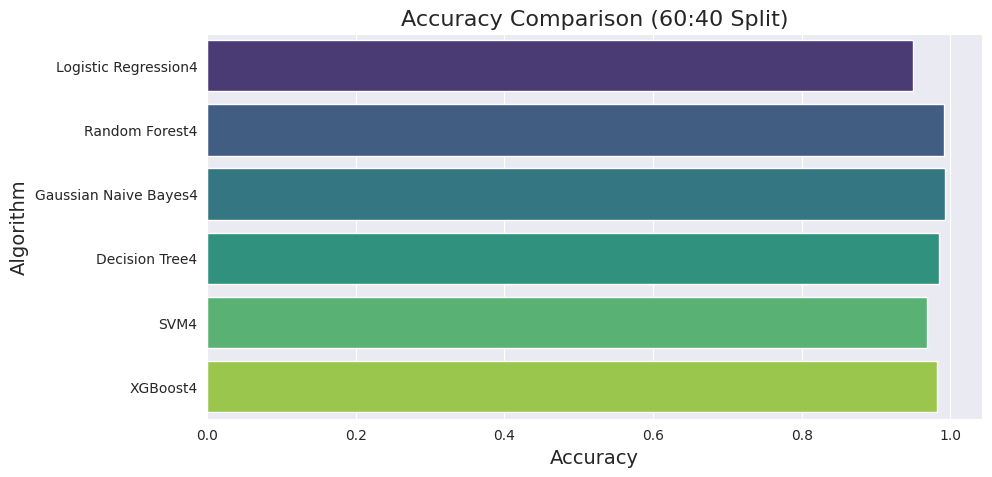

Logistic Regression4 --> 0.95
Random Forest4 --> 0.9920454545454546
Gaussian Naive Bayes4 --> 0.9931818181818182
Decision Tree4 --> 0.9852272727272727
SVM4 --> 0.9681818181818181
XGBoost4 --> 0.9818181818181818


In [84]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
plt.figure(figsize=[10,5], dpi=100)
plt.title('Accuracy Comparison (60:40 Split)', fontsize=16)
plt.xlabel('Accuracy', fontsize=14)
plt.ylabel('Algorithm', fontsize=14)

# Customize the barplot
sns.barplot(x=acc4, y=model4, palette='viridis')

# Show the plot
plt.show()

# Display accuracy values for each model
accuracy_models = dict(zip(model4, acc4))
for k, v in accuracy_models.items():
    print (k, '-->', v)


# Train and Test Ratio are 50:50

In [85]:
xtrain5,xtest5,ytrain5,ytest5=train_test_split(x,y,test_size=0.5,random_state=42)

In [86]:
models={'Logistic Regression5':LogisticRegression(),
        'Random Forest5':RandomForestClassifier(),
        'Tree5':DecisionTreeClassifier(),
        'SVC5':SVC(),
        'xGBoost5':XGBClassifier()
       }
def fit_and_Score(models,xtrain,xtest,ytrain,ytest):
    np.random.seed(42)
    model_score={}
    for name,model in models.items():
        model.fit(xtrain,ytrain)
        model_score[name]=model.score(xtest,ytest)
    return model_score

In [87]:
model_score= fit_and_Score(models,xtrain5,xtest5,ytrain5,ytest5)
model_score

{'Logistic Regression5': 0.9490909090909091,
 'Random Forest5': 0.9936363636363637,
 'Tree5': 0.9781818181818182,
 'SVC5': 0.9654545454545455,
 'xGBoost5': 0.980909090909091}

In [88]:
acc5 =[]
model5 =[]

In [89]:
# Logistic Regression
model_lr5 = LogisticRegression(random_state=42)
model_lr5.fit(xtrain5, ytrain5)

# Train and test accuracy
train_score_lr5 = model_lr5.score(xtrain5, ytrain5)
test_score_lr5 = model_lr5.score(xtest5, ytest5)
print("Logistic Regression Train Accuracy for 50:", train_score_lr5)
print("Logistic Regression Test Accuracy for 50:", test_score_lr5)

# Append accuracy and model name to lists
acc5.append(test_score_lr5)
model5.append('Logistic Regression5')
models_lr.append('Logistic Regression5')
accuracy_test_lr.append(test_score_lr5)
accuracy_train_lr.append(train_score_lr5)

# Predictions and evaluation
y_pred_lr5 = model_lr5.predict(xtest5)
lr_acc5 = accuracy_score(y_pred_lr5, ytest5)
print(f"Accuracy Score: {lr_acc5:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest5
y_pred_current = y_pred_lr5

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")


Logistic Regression Train Accuracy for 50: 0.9772727272727273
Logistic Regression Test Accuracy for 50: 0.9490909090909091
Accuracy Score: 0.9491
Precision: 0.9501
Recall: 0.9491
F1 Score: 0.9487


In [90]:
# Random Forest
model_rf5 = RandomForestClassifier(random_state=42)
model_rf5.fit(xtrain5, ytrain5)

# Train and test accuracy
train_score_rf5 = model_rf5.score(xtrain5, ytrain5)
test_score_rf5 = model_rf5.score(xtest5, ytest5)
print("Random Forest Train Accuracy for 50:", train_score_rf5)
print("Random Forest Test Accuracy for 50:", test_score_rf5)

# Append accuracy and model name to lists
acc5.append(test_score_rf5)
model5.append('Random Forest5')
models_rf.append('Random Forest5')
accuracy_test_rf.append(test_score_rf5)
accuracy_train_rf.append(train_score_rf5)

# Predictions and evaluation
y_pred_rf5 = model_rf5.predict(xtest5)
rf_acc5 = accuracy_score(y_pred_rf5, ytest5)
print(f"Accuracy Score: {rf_acc5:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest5
y_pred_current = y_pred_rf5

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Random Forest Train Accuracy for 50: 1.0
Random Forest Test Accuracy for 50: 0.9936363636363637
Accuracy Score: 0.9936
Precision: 0.9939
Recall: 0.9936
F1 Score: 0.9936


In [91]:
# Gaussian Naive Bayes
model_nb5 = GaussianNB()
model_nb5.fit(xtrain5, ytrain5)

# Train and test accuracy
train_score_nb5 = model_nb5.score(xtrain5, ytrain5)
test_score_nb5 = model_nb5.score(xtest5, ytest5)
print("Gaussian Naive Bayes Train Accuracy for 50:", train_score_nb5)
print("Gaussian Naive Bayes Test Accuracy for 50:", test_score_nb5)

# Append accuracy and model name to lists
acc5.append(test_score_nb5)
model5.append('Gaussian Naive Bayes5')
models_nb.append('Gaussian Naive Bayes5')
accuracy_test_nb.append(test_score_nb5)
accuracy_train_nb.append(train_score_nb5)

# Predictions and evaluation
y_pred_nb5 = model_nb5.predict(xtest5)
nb_acc5 = accuracy_score(y_pred_nb5, ytest5)
print(f"Accuracy Score: {nb_acc5:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest5
y_pred_current = y_pred_nb5

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Gaussian Naive Bayes Train Accuracy for 50: 0.9963636363636363
Gaussian Naive Bayes Test Accuracy for 50: 0.9936363636363637
Accuracy Score: 0.9936
Precision: 0.9938
Recall: 0.9936
F1 Score: 0.9936


In [92]:
# Decision Tree
model_dt5 = DecisionTreeClassifier(random_state=42)
model_dt5.fit(xtrain5, ytrain5)

# Train and test accuracy
train_score_dt5 = model_dt5.score(xtrain5, ytrain5)
test_score_dt5 = model_dt5.score(xtest5, ytest5)
print("Decision Tree Train Accuracy for 50:", train_score_dt5)
print("Decision Tree Test Accuracy for 50:", test_score_dt5)


# Append accuracy and model name to lists
acc5.append(test_score_dt5)
model5.append('Decision Tree5')
models_dt.append('Decision Tree5')
accuracy_test_dt.append(test_score_dt5)
accuracy_train_dt.append(train_score_dt5)

# Predictions and evaluation
y_pred_dt5 = model_dt5.predict(xtest5)
dt_acc5 = accuracy_score(y_pred_dt5, ytest5)
print(f"Accuracy Score: {dt_acc5:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest5
y_pred_current = y_pred_dt5

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

Decision Tree Train Accuracy for 50: 1.0
Decision Tree Test Accuracy for 50: 0.9772727272727273
Accuracy Score: 0.9773
Precision: 0.9777
Recall: 0.9773
F1 Score: 0.9773


In [93]:
# Support Vector Machine (SVM)
model_svm5 = SVC(random_state=42)
model_svm5.fit(xtrain5, ytrain5)

# Train and test accuracy
train_score_svm5 = model_svm5.score(xtrain5, ytrain5)
test_score_svm5 = model_svm5.score(xtest5, ytest5)
print("SVM Train Accuracy for 50:", train_score_svm5)
print("SVM Test Accuracy for 50:", test_score_svm5)

# Append accuracy and model name to lists
acc5.append(test_score_svm5)
model5.append('SVM5')
models_svm.append('SVM5')
accuracy_test_svm.append(test_score_svm5)
accuracy_train_svm.append(train_score_svm5)

# Predictions and evaluation
y_pred_svm5 = model_svm5.predict(xtest5)
svm_acc5 = accuracy_score(y_pred_svm5, ytest5)
print(f"Accuracy Score: {svm_acc5:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest5
y_pred_current = y_pred_svm5

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

SVM Train Accuracy for 50: 0.98
SVM Test Accuracy for 50: 0.9654545454545455
Accuracy Score: 0.9655
Precision: 0.9702
Recall: 0.9655
F1 Score: 0.9650


In [94]:
#XGBoost
model_xg5 = XGBClassifier(random_state=42)
model_xg5.fit(xtrain5,ytrain5)

# Train and test accuracy
train_score_xgb5 = model_xg5.score(xtrain5, ytrain5)
test_score_xgb5 = model_xg5.score(xtest5, ytest5)
print("XGBoost Train Accuracy for 50:", train_score_xgb5)
print("XGBoost Test Accuracy for 50:", test_score_xgb5)
# Append accuracy and model name to lists
acc5.append(test_score_xgb5)
model5.append('XGBoost5')
models_xg.append('XGBoost5')
accuracy_test_xg.append(test_score_xgb5)
accuracy_train_xg.append(train_score_xgb5)

# Predictions and evaluation
y_pred_xg5 = model_xg5.predict(xtest5)
xg_acc5 = accuracy_score(y_pred_xg5, ytest5)
print(f"Accuracy Score: {xg_acc5:.4f}")

# Calculate Precision, Recall, and F1 Score
y_true_current = ytest5
y_pred_current = y_pred_xg5

precision_current = precision_score(y_true_current, y_pred_current, average='weighted')
print(f"Precision: {precision_current:.4f}")

recall_current = recall_score(y_true_current, y_pred_current, average='weighted')
print(f"Recall: {recall_current:.4f}")

f1_current = f1_score(y_true_current, y_pred_current, average='weighted')
print(f"F1 Score: {f1_current:.4f}")

XGBoost Train Accuracy for 50: 1.0
XGBoost Test Accuracy for 50: 0.980909090909091
Accuracy Score: 0.9809
Precision: 0.9818
Recall: 0.9809
F1 Score: 0.9809


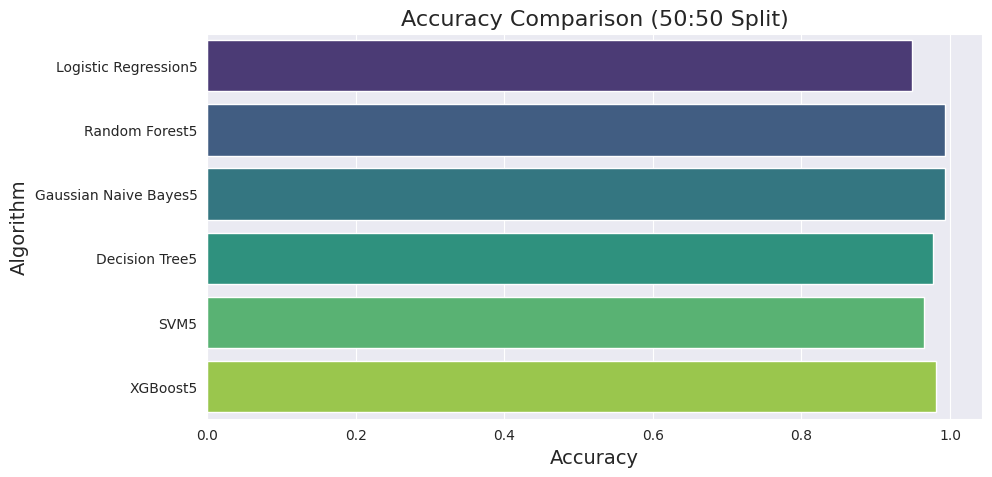

Logistic Regression5 --> 0.9490909090909091
Random Forest5 --> 0.9936363636363637
Gaussian Naive Bayes5 --> 0.9936363636363637
Decision Tree5 --> 0.9772727272727273
SVM5 --> 0.9654545454545455
XGBoost5 --> 0.980909090909091


In [95]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
plt.figure(figsize=[10,5], dpi=100)
plt.title('Accuracy Comparison (50:50 Split)', fontsize=16)
plt.xlabel('Accuracy', fontsize=14)
plt.ylabel('Algorithm', fontsize=14)

# Customize the barplot
sns.barplot(x=acc5, y=model5, palette='viridis')

# Show the plot
plt.show()

# Display accuracy values for each model
accuracy_models = dict(zip(model5, acc5))
for k, v in accuracy_models.items():
    print (k, '-->', v)


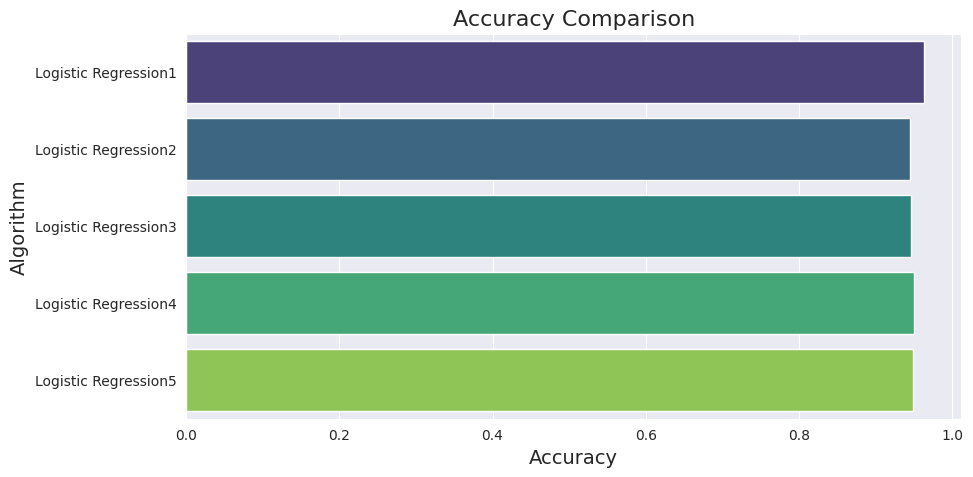

Logistic Regression1 --> 0.9636363636363636
Logistic Regression2 --> 0.9454545454545454
Logistic Regression3 --> 0.946969696969697
Logistic Regression4 --> 0.95
Logistic Regression5 --> 0.9490909090909091


In [96]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
plt.figure(figsize=[10,5], dpi=100)
plt.title('Accuracy Comparison', fontsize=16)
plt.xlabel('Accuracy', fontsize=14)
plt.ylabel('Algorithm', fontsize=14)

# Customize the barplot
sns.barplot(x=accuracy_test_lr, y=models_lr, palette='viridis')

# Show the plot
plt.show()

# Display accuracy values for each model
accuracy_models = dict(zip(models_lr, accuracy_test_lr))
for k, v in accuracy_models.items():
    print (k, '-->', v)

# Comparision b/w train and test accuracy for different models of logistic Regression

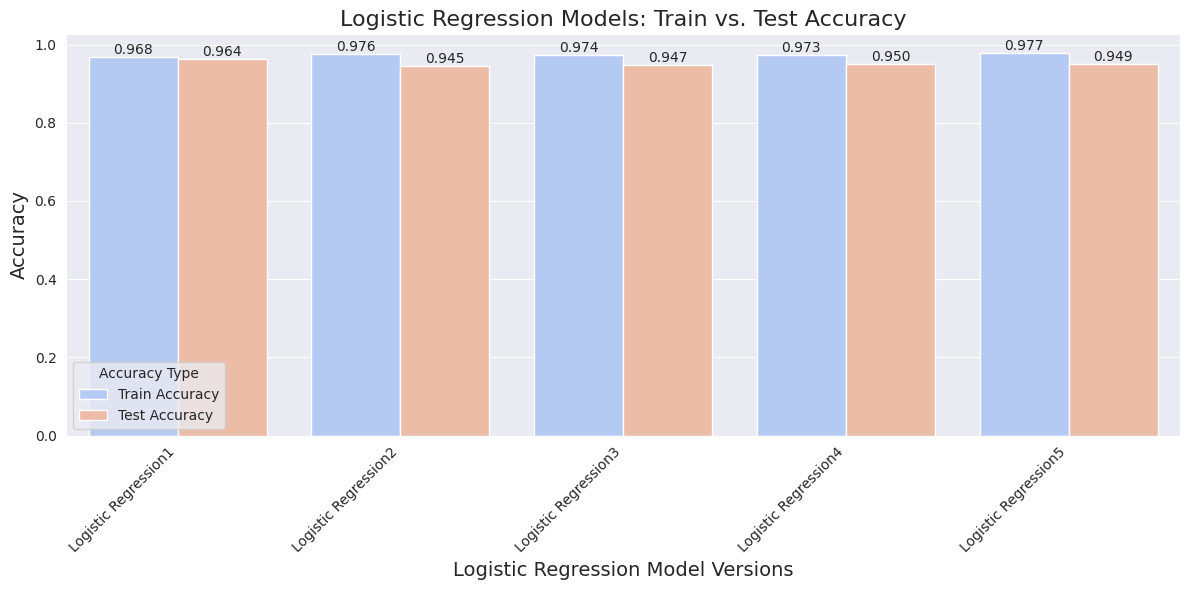

In [97]:
lr_accuracy_data = pd.DataFrame({
    'Model': models_lr,
    'Train Accuracy': accuracy_train_lr,
    'Test Accuracy': accuracy_test_lr
})

# Melt the DataFrame to long format for easier plotting with seaborn
lr_accuracy_melted = lr_accuracy_data.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=[12, 6], dpi=100)
ax = sns.barplot(x='Model', y='Accuracy', hue='Metric', data=lr_accuracy_melted, palette='coolwarm')
plt.title('Logistic Regression Models: Train vs. Test Accuracy', fontsize=16)
plt.xlabel('Logistic Regression Model Versions', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
# Removed: plt.ylim(0.9, 1.0) # Set y-axis limits to focus on accuracy range
plt.legend(title='Accuracy Type')

# Add accuracy values on top of the bars manually
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

# Comparision b/w train and test accuracy for different models of Random Forest


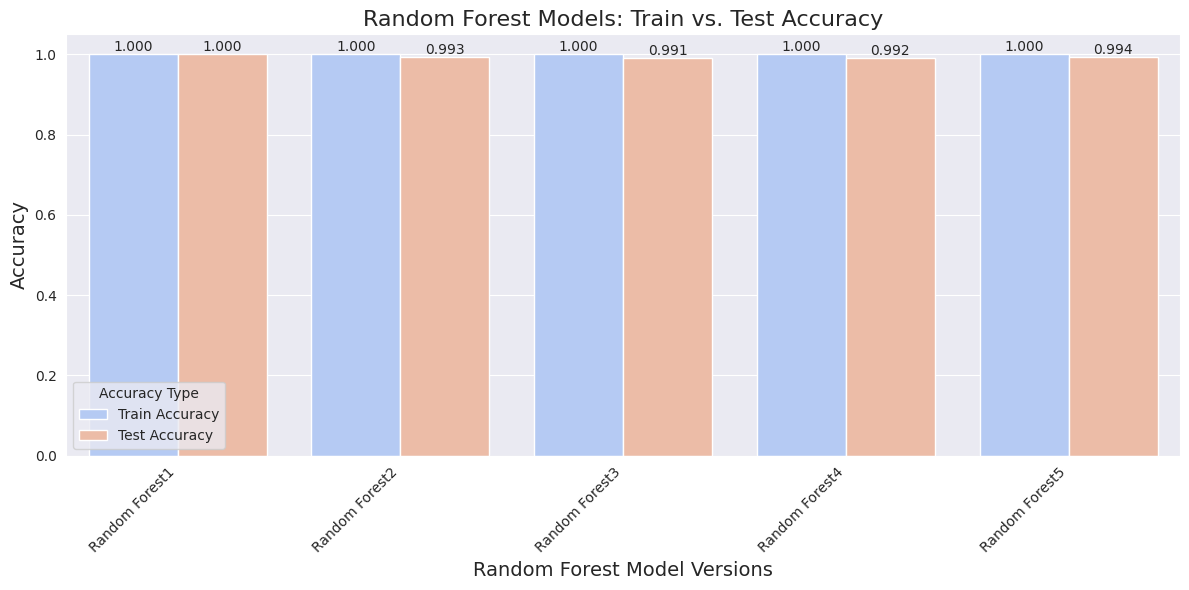

In [98]:
rf_accuracy_data = pd.DataFrame({
    'Model': models_rf,
    'Train Accuracy': accuracy_train_rf,
    'Test Accuracy': accuracy_test_rf
})

# Melt the DataFrame to long format for easier plotting with seaborn
rf_accuracy_melted = rf_accuracy_data.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=[12, 6], dpi=100)
ax = sns.barplot(x='Model', y='Accuracy', hue='Metric', data=rf_accuracy_melted, palette='coolwarm')
plt.title('Random Forest Models: Train vs. Test Accuracy', fontsize=16)
plt.xlabel('Random Forest Model Versions', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
# plt.ylim(0.9, 1.0) # Set y-axis limits to focus on accuracy range
plt.legend(title='Accuracy Type')

# Add accuracy values on top of the bars manually
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

# Comparision b/w train and test accuracy for different models of Gaussian Naive Bayes2

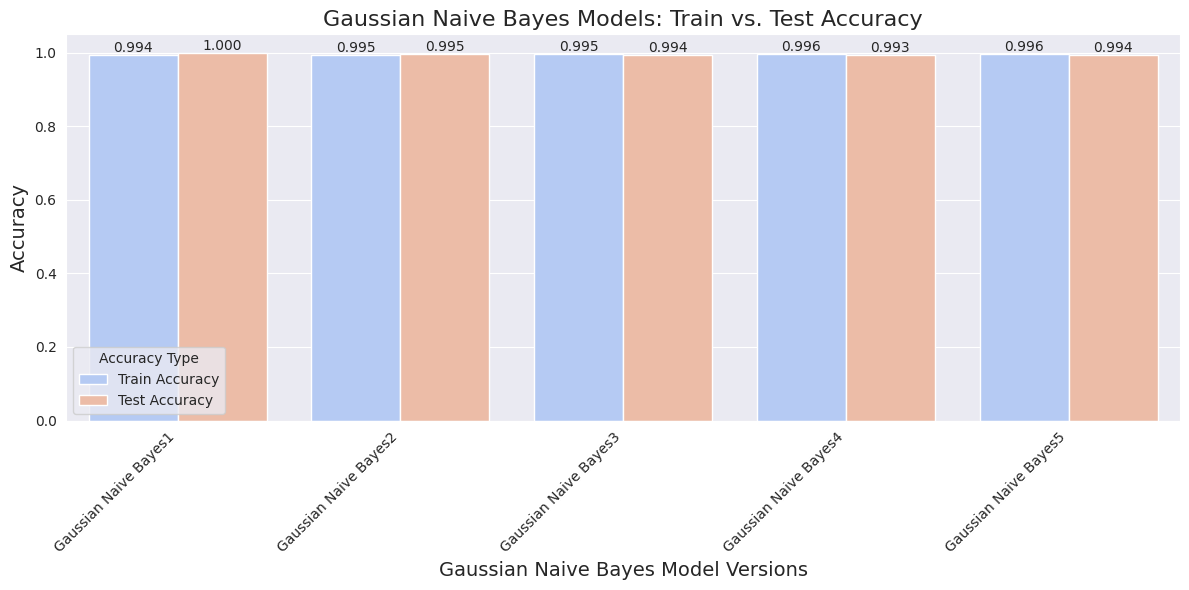

In [99]:
nb_accuracy_data = pd.DataFrame({
    'Model': models_nb,
    'Train Accuracy': accuracy_train_nb,
    'Test Accuracy': accuracy_test_nb
})

# Melt the DataFrame to long format for easier plotting with seaborn
nb_accuracy_melted = nb_accuracy_data.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=[12, 6], dpi=100)
ax = sns.barplot(x='Model', y='Accuracy', hue='Metric', data=nb_accuracy_melted, palette='coolwarm')
plt.title('Gaussian Naive Bayes Models: Train vs. Test Accuracy', fontsize=16)
plt.xlabel('Gaussian Naive Bayes Model Versions', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
# plt.ylim(0.9, 1.0) # Set y-axis limits to focus on accuracy range
plt.legend(title='Accuracy Type')

# Add accuracy values on top of the bars manually
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

# Comparision b/w train and test accuracy for different models of Desicion Tree

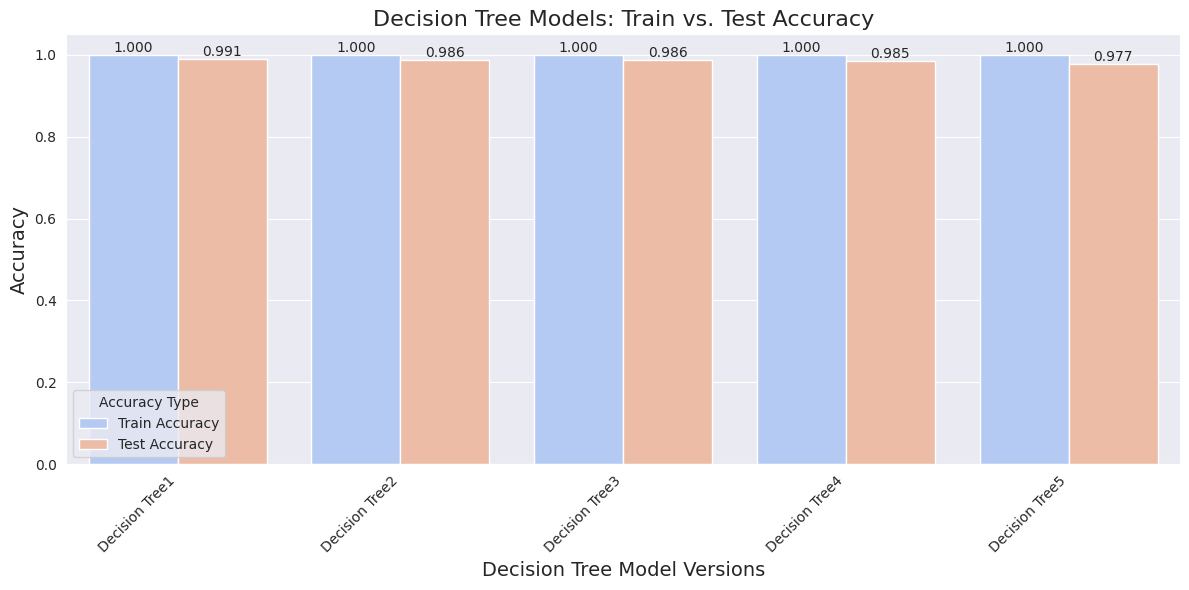

In [100]:
dt_accuracy_data = pd.DataFrame({
    'Model': models_dt,
    'Train Accuracy': accuracy_train_dt,
    'Test Accuracy': accuracy_test_dt
})

# Melt the DataFrame to long format for easier plotting with seaborn
dt_accuracy_melted = dt_accuracy_data.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=[12, 6], dpi=100)
ax = sns.barplot(x='Model', y='Accuracy', hue='Metric', data=dt_accuracy_melted, palette='coolwarm')
plt.title('Decision Tree Models: Train vs. Test Accuracy', fontsize=16)
plt.xlabel('Decision Tree Model Versions', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
# plt.ylim(0.9, 1.0) # Set y-axis limits to focus on accuracy range
plt.legend(title='Accuracy Type')

# Add accuracy values on top of the bars manually
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

# Comparision b/w train and test accuracy for different models of Support Vector Machine


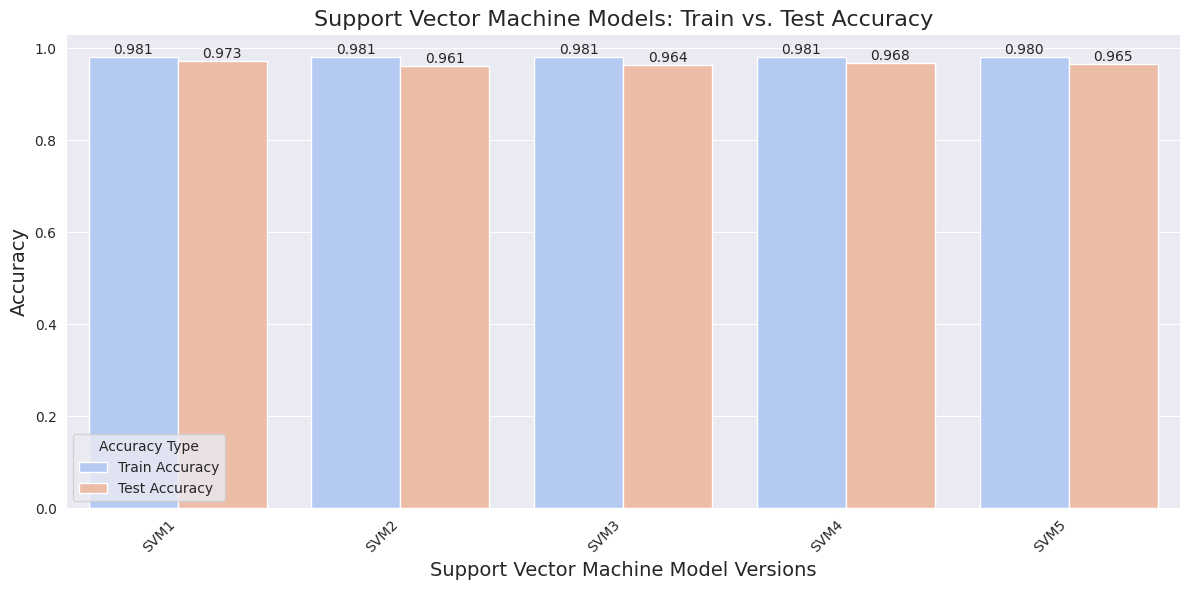

In [101]:
svm_accuracy_data = pd.DataFrame({
    'Model': models_svm,
    'Train Accuracy': accuracy_train_svm,
    'Test Accuracy': accuracy_test_svm
})

# Melt the DataFrame to long format for easier plotting with seaborn
svm_accuracy_melted = svm_accuracy_data.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=[12, 6], dpi=100)
ax = sns.barplot(x='Model', y='Accuracy', hue='Metric', data=svm_accuracy_melted, palette='coolwarm')
plt.title('Support Vector Machine Models: Train vs. Test Accuracy', fontsize=16)
plt.xlabel('Support Vector Machine Model Versions', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
# plt.ylim(0.9, 1.0) # Set y-axis limits to focus on accuracy range
plt.legend(title='Accuracy Type')

# Add accuracy values on top of the bars manually
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

# Comparision b/w train and test accuracy for different models of XGBoost


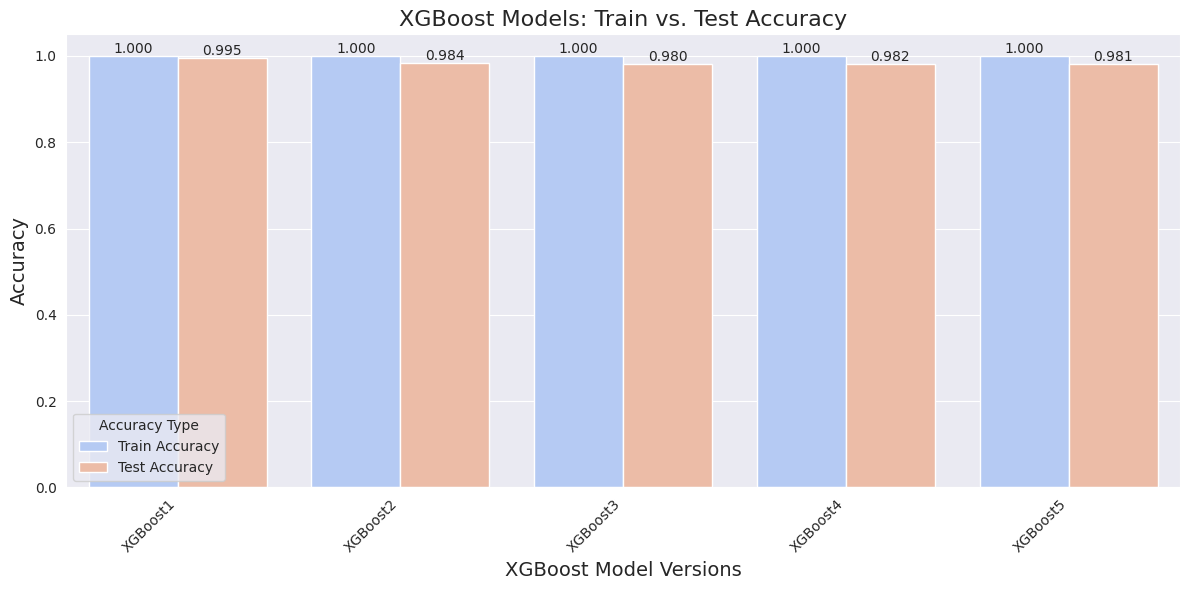

In [102]:
xg_accuracy_data = pd.DataFrame({
    'Model': models_xg,
    'Train Accuracy': accuracy_train_xg,
    'Test Accuracy': accuracy_test_xg
})

# Melt the DataFrame to long format for easier plotting with seaborn
xg_accuracy_melted = xg_accuracy_data.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=[12, 6], dpi=100)
ax = sns.barplot(x='Model', y='Accuracy', hue='Metric', data=xg_accuracy_melted, palette='coolwarm')
plt.title('XGBoost Models: Train vs. Test Accuracy', fontsize=16)
plt.xlabel('XGBoost Model Versions', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
# plt.ylim(0.9, 1.0) # Set y-axis limits to focus on accuracy range
plt.legend(title='Accuracy Type')

# Add accuracy values on top of the bars manually
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()